In [1]:
library(pheatmap)
library(ggplot2)
library(data.table)   # before reshape2: both define melt()
library(reshape2)

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x and silently breaks every "+"
# chain, producing a blank PDF. %ni% and save_pheatmap_pdf are inlined from
# Utilities.R.

`%ni%` <- Negate(`%in%`)

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

# Terms are keyed by the old module names ("K_0", "K_0:K_1", "K0:K0"), so the
# tables are indexed with those and relabelled only where they are displayed.
MODULE_OF_K <- c("0" = "M2", "1" = "M3", "2" = "M6", "3" = "M5", "4" = "M1", "5" = "M4")

moduleLabel <- function(x) {
    for (k in names(MODULE_OF_K)) x <- gsub(paste0("K_?", k), MODULE_OF_K[[k]], x)
    x
}



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt




In [2]:
annoCols<-list(GeneGroup=c(G0='#A6CEE3',
                           G1='#1F78B4',
                           G2='#B2DF8A',
                           G3='#33A02C', 
                           G4='#FB9A99', 
                           G5='#FDBF6F', 
                           G6='#FF7F00', 
                           G7='#CAB2D6',
                           G8='#6A3D9A', 
                           G9='#FFFF99', 
                           G10="#B5651D" ),
                 GuideGroup=c(M2="#1f77b4",
                              M3="#ff7f0e",
                              M6="#279e68",
                              M5="#d62728", 
                              M1="#aa40fc", 
                              M4="#8c564b"))

myGeneModules = data.frame(read.csv("/home/eraslab1/Projects/E3Ligase/analysisSingle/TextFiles/ME_GeneModules_leiden_11_Modules.csv",
                                    row.names=1,
                                    stringsAsFactors = FALSE), stringsAsFactors = FALSE)

myGeneModules$GeneName[myGeneModules$GeneName == "X2010111I01Rik"] = "2010111I01Rik"
myGeneModules$GeneName[myGeneModules$GeneName == "X0610012G03Rik"] = "0610012G03Rik"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.M2"] = "H2-M2"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.Q6"] = "H2-Q6"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.Q7"] = "H2-Q7"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.D1"] = "H2-D1"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.K1"] = "H2-K1"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.T23"] = "H2-T23"
myGeneModules$GeneName[myGeneModules$GeneName == "X2010005H15Rik"] = "2010005H15Rik"
myGeneModules$GeneName[myGeneModules$GeneName == "X2310001H17Rik"] = "2310001H17Rik"
myGeneModules$GeneName[myGeneModules$GeneName == "X2810474O19Rik"] = "2810474O19Rik"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.Aa"] = "H2-Aa"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.Ab1"] = "H2-Ab1"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.DMa"] = "H2-DMa"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.DMb1"] = "H2-DMb1"
myGeneModules$GeneName[myGeneModules$GeneName == "H2.Eb1"] = "H2-Eb1"

rownames(myGeneModules) <- myGeneModules$GeneName
myGeneModules[c("GeneName", "NewGeneGroup", "GeneColor")] <- NULL
myGeneModules$GeneGroup <- factor(myGeneModules$GeneGroup)


In [3]:
doubleRes <- readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ComboEffects_doublesResampleRes.rds")
rownames(doubleRes) = doubleRes$respGene
doubleRes$respGene = NULL
head(doubleRes)

,K0:K0,K1:K1,K2:K2,K3:K3,K4:K4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610012G03Rik,0,0.00000000,0.000000,0.00000000,0.0000000
2010005H15Rik,0,-0.08023992,-0.102160,-0.08825271,0.0000000
2010111I01Rik,0,0.00000000,0.000000,0.00000000,-0.3068648
2310001H17Rik,0,0.00000000,0.178393,0.00000000,0.0000000
2810474O19Rik,0,0.00000000,0.000000,0.00000000,0.0000000
AA467197,0,0.00000000,0.000000,0.00000000,0.0000000


In [4]:
combosInter <- readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ComboEffects_lm_residuals_withInteractions.rds")
combosInter <- combosInter[combosInter$term %ni% c("(Intercept)", 
                                                   "n_genes", 
                                                   "mt_frac", 
                                                   paste0("leiden", 1:9)),]
combosInter = data.table(combosInter)
combosInter[,FDR:=p.adjust(p.value, 
                           method = "fdr", 
                           n = length(p.value)),
            by=respGene]
combosInter = data.frame(combosInter)



combosInterFDR = copy(combosInter)
combosInter[,c("std.error", "statistic", "p.value","FDR")] = NULL
combosInter = reshape(combosInter, 
                      idvar = "respGene", 
                      timevar = "term", 
                      direction = "wide")
rownames(combosInter) = combosInter$respGene
combosInter$respGene = NULL
colnames(combosInter) = sapply( colnames(combosInter), 
                               function(x){strsplit(x,"estimate.")[[1]][2]})

combosInterCopy = copy(combosInter)


combosInterFDR[,c("std.error", "statistic", "estimate", "p.value")] = NULL
combosInterFDR = reshape(combosInterFDR, 
                         idvar = "respGene", 
                         timevar = "term",  
                         direction = "wide")
rownames(combosInterFDR) = combosInterFDR$respGene
combosInterFDR$respGene = NULL
colnames(combosInterFDR) = sapply( colnames(combosInterFDR), 
                                  function(x){strsplit(x,"FDR.")[[1]][2]})


combosInter[combosInterFDR > 0.1] = 0

In [5]:
cMean1 = data.frame(readRDS("/home/eraslab1/Projects/E3Ligase/analysisSingle/Notebooks/CombinatorialPerturbations/RDSFiles/ControlCellsMeanExp.rds"), stringsAsFactors = FALSE)
rownames(cMean1) = cMean1$Genes
cMean1$Genes = NULL
cMean1 = data.frame(scale(cMean1, 
                          center = TRUE, 
                          scale = FALSE), 
                    stringsAsFactors = FALSE)

write.csv(combosInter, "outputs/CombosInter.csv")

In [6]:
doubleRes = doubleRes[rownames(combosInter),]
combosInter = cbind(combosInter, doubleRes)
combosInterPlot = copy(combosInter)
colnames(combosInterPlot) <- moduleLabel(colnames(combosInterPlot))

combosInterPlot = combosInterPlot[rownames(myGeneModules),]
combosInterPlot[combosInterPlot > 0.2] =0.2
combosInterPlot[combosInterPlot <  -0.2] = -0.2

combosInterPlot <- t(combosInterPlot)
initialRowNames = rownames(combosInterPlot)


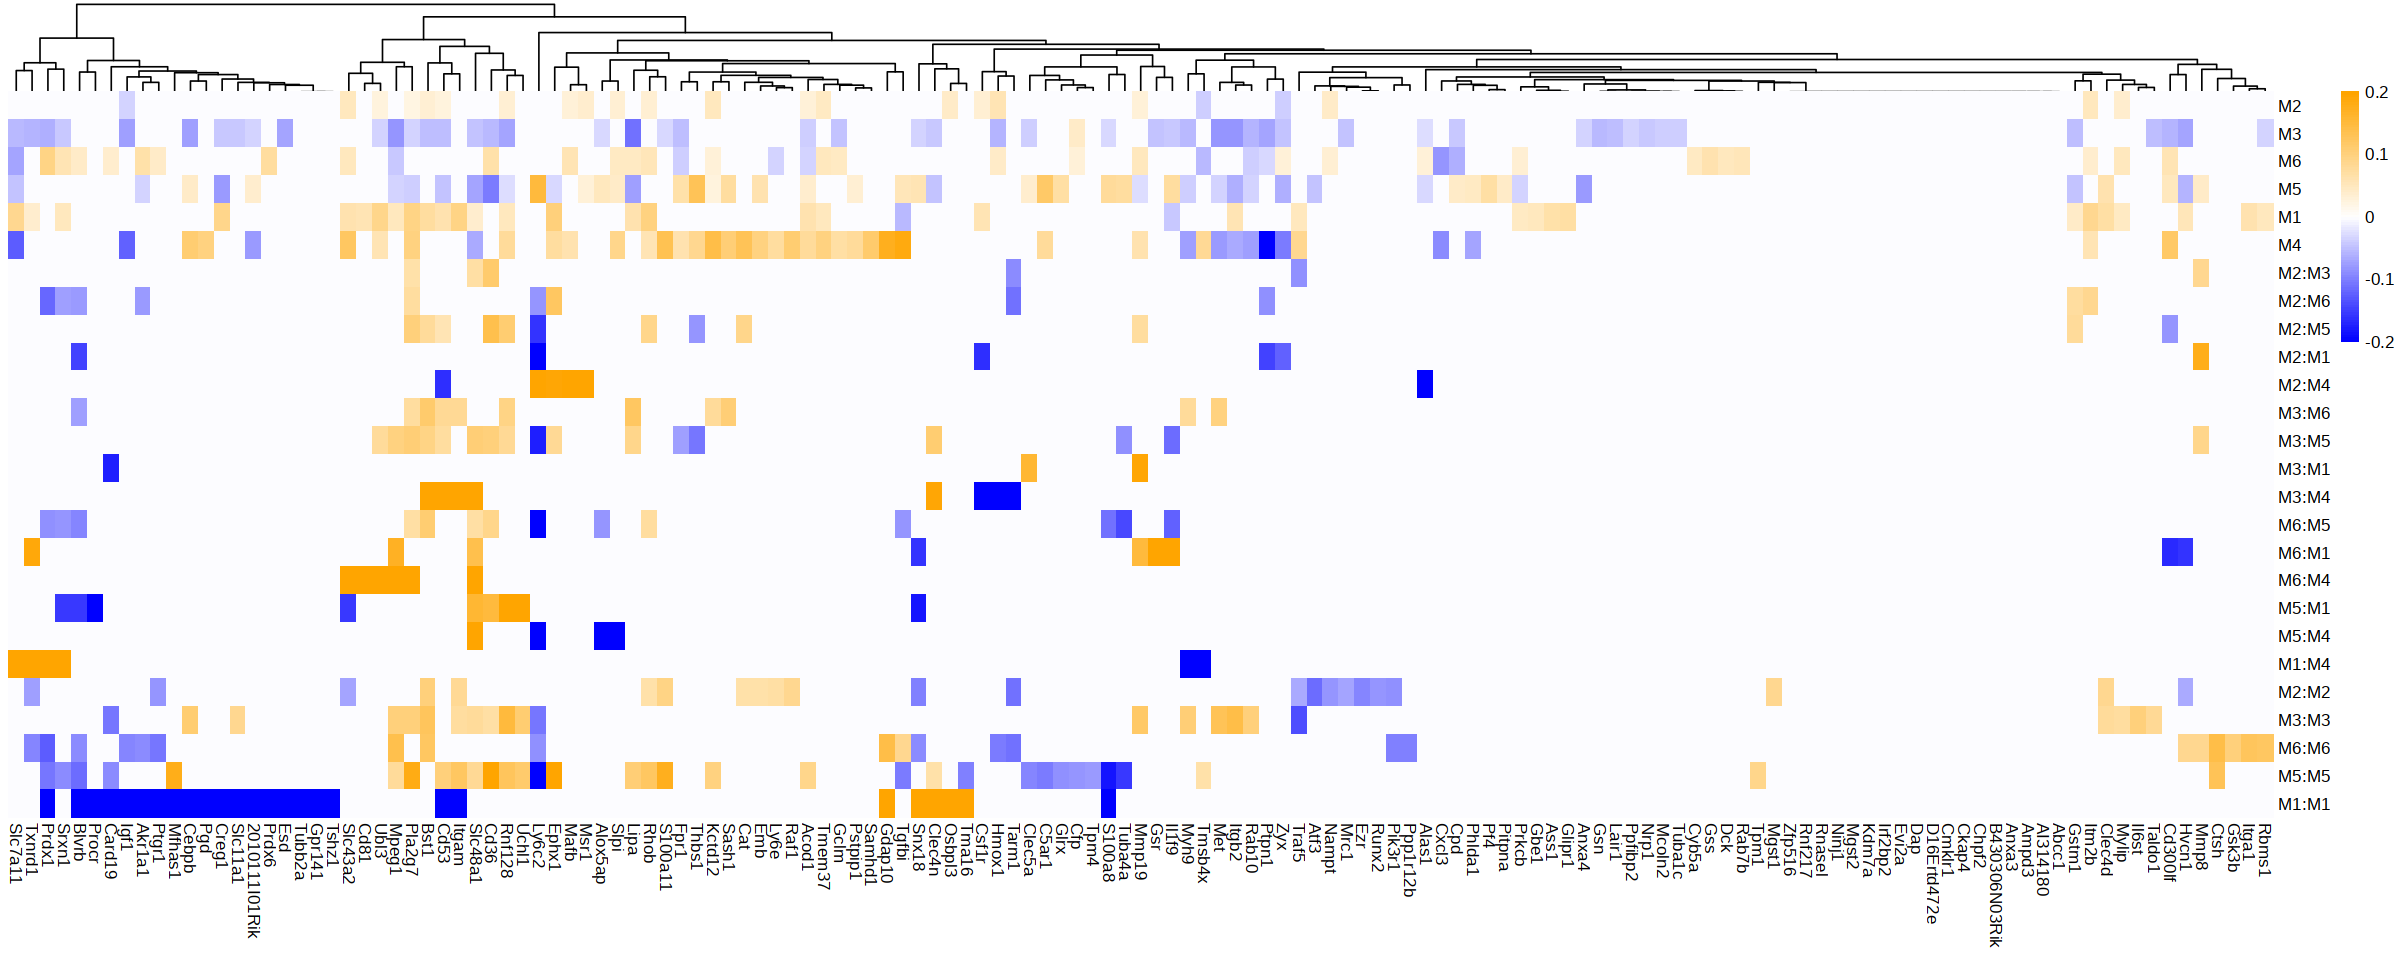

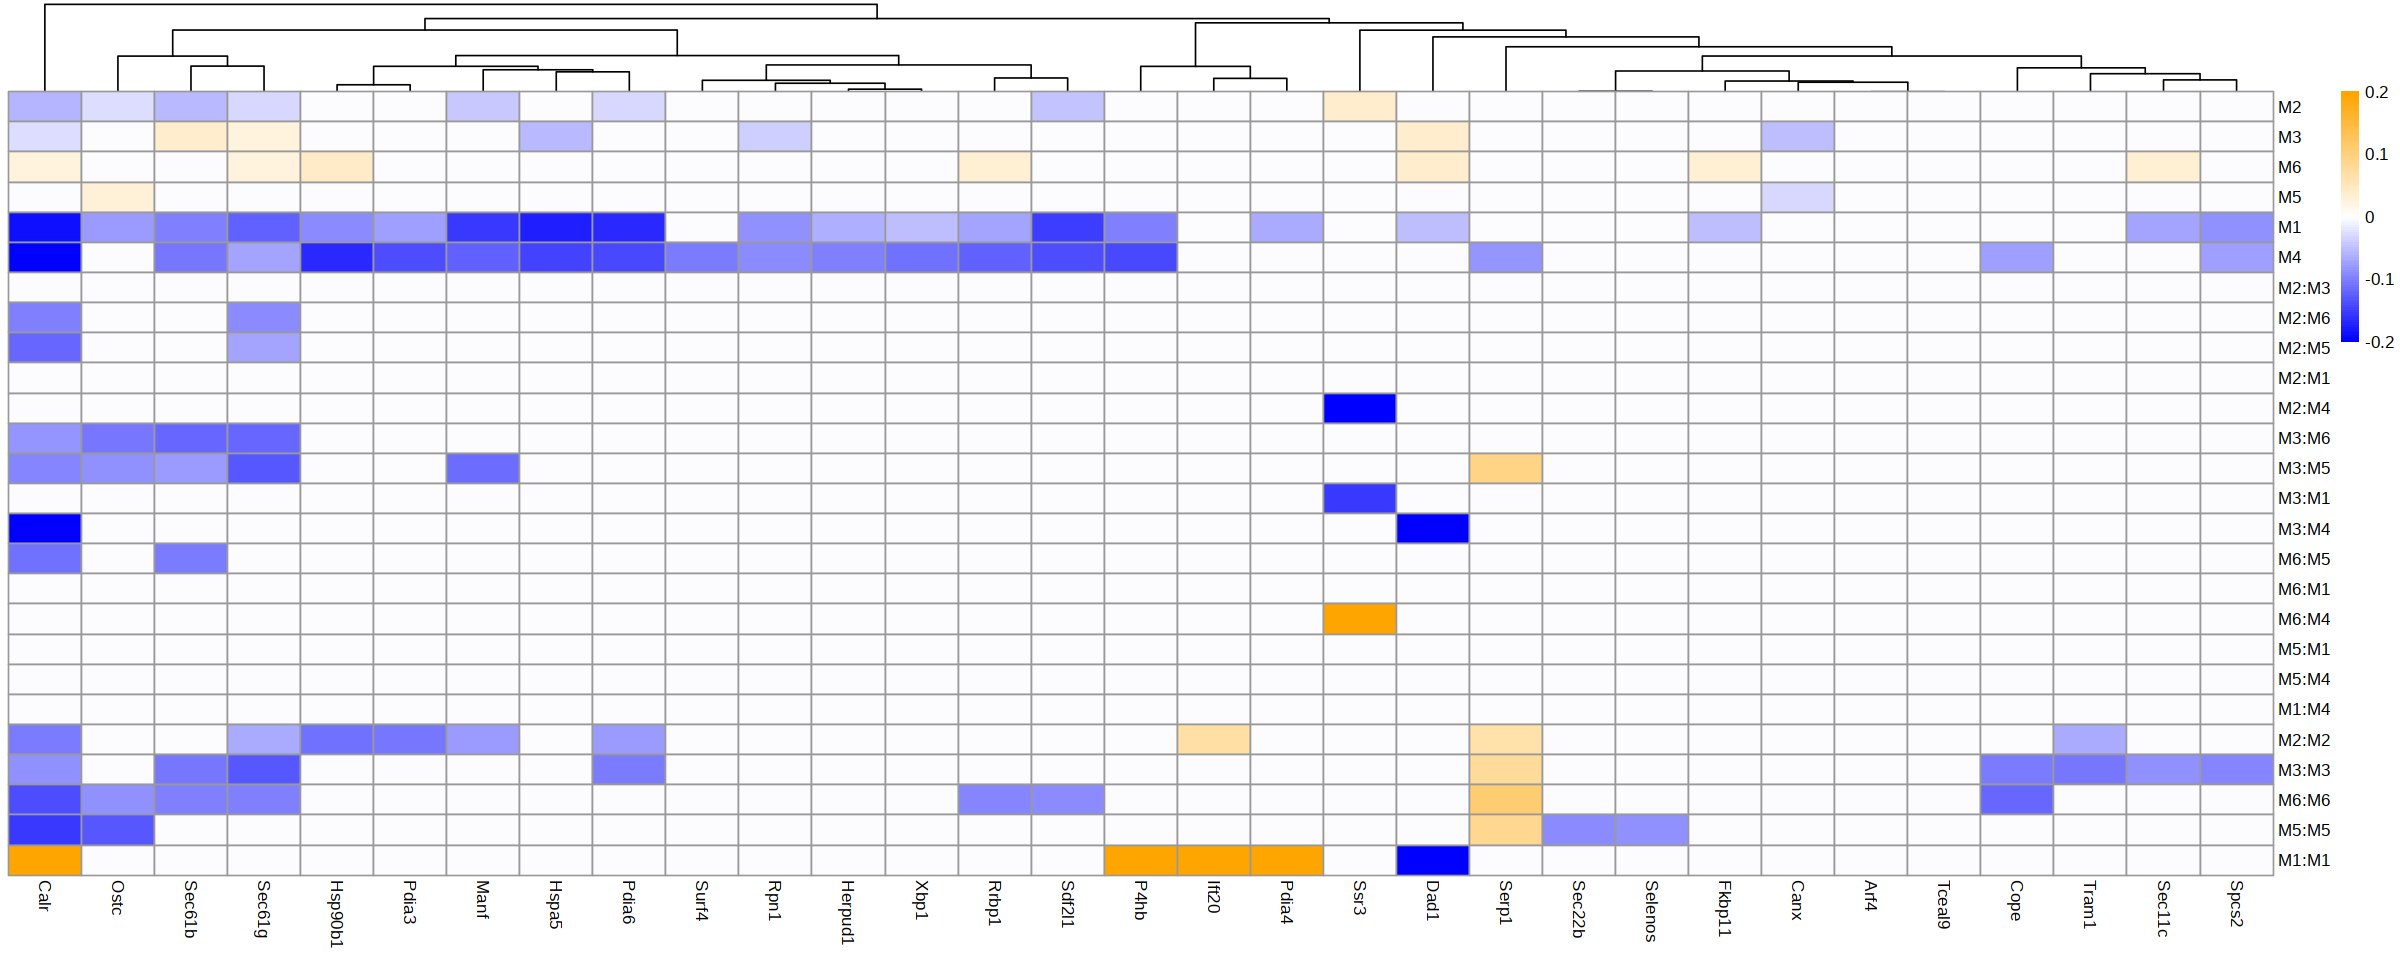

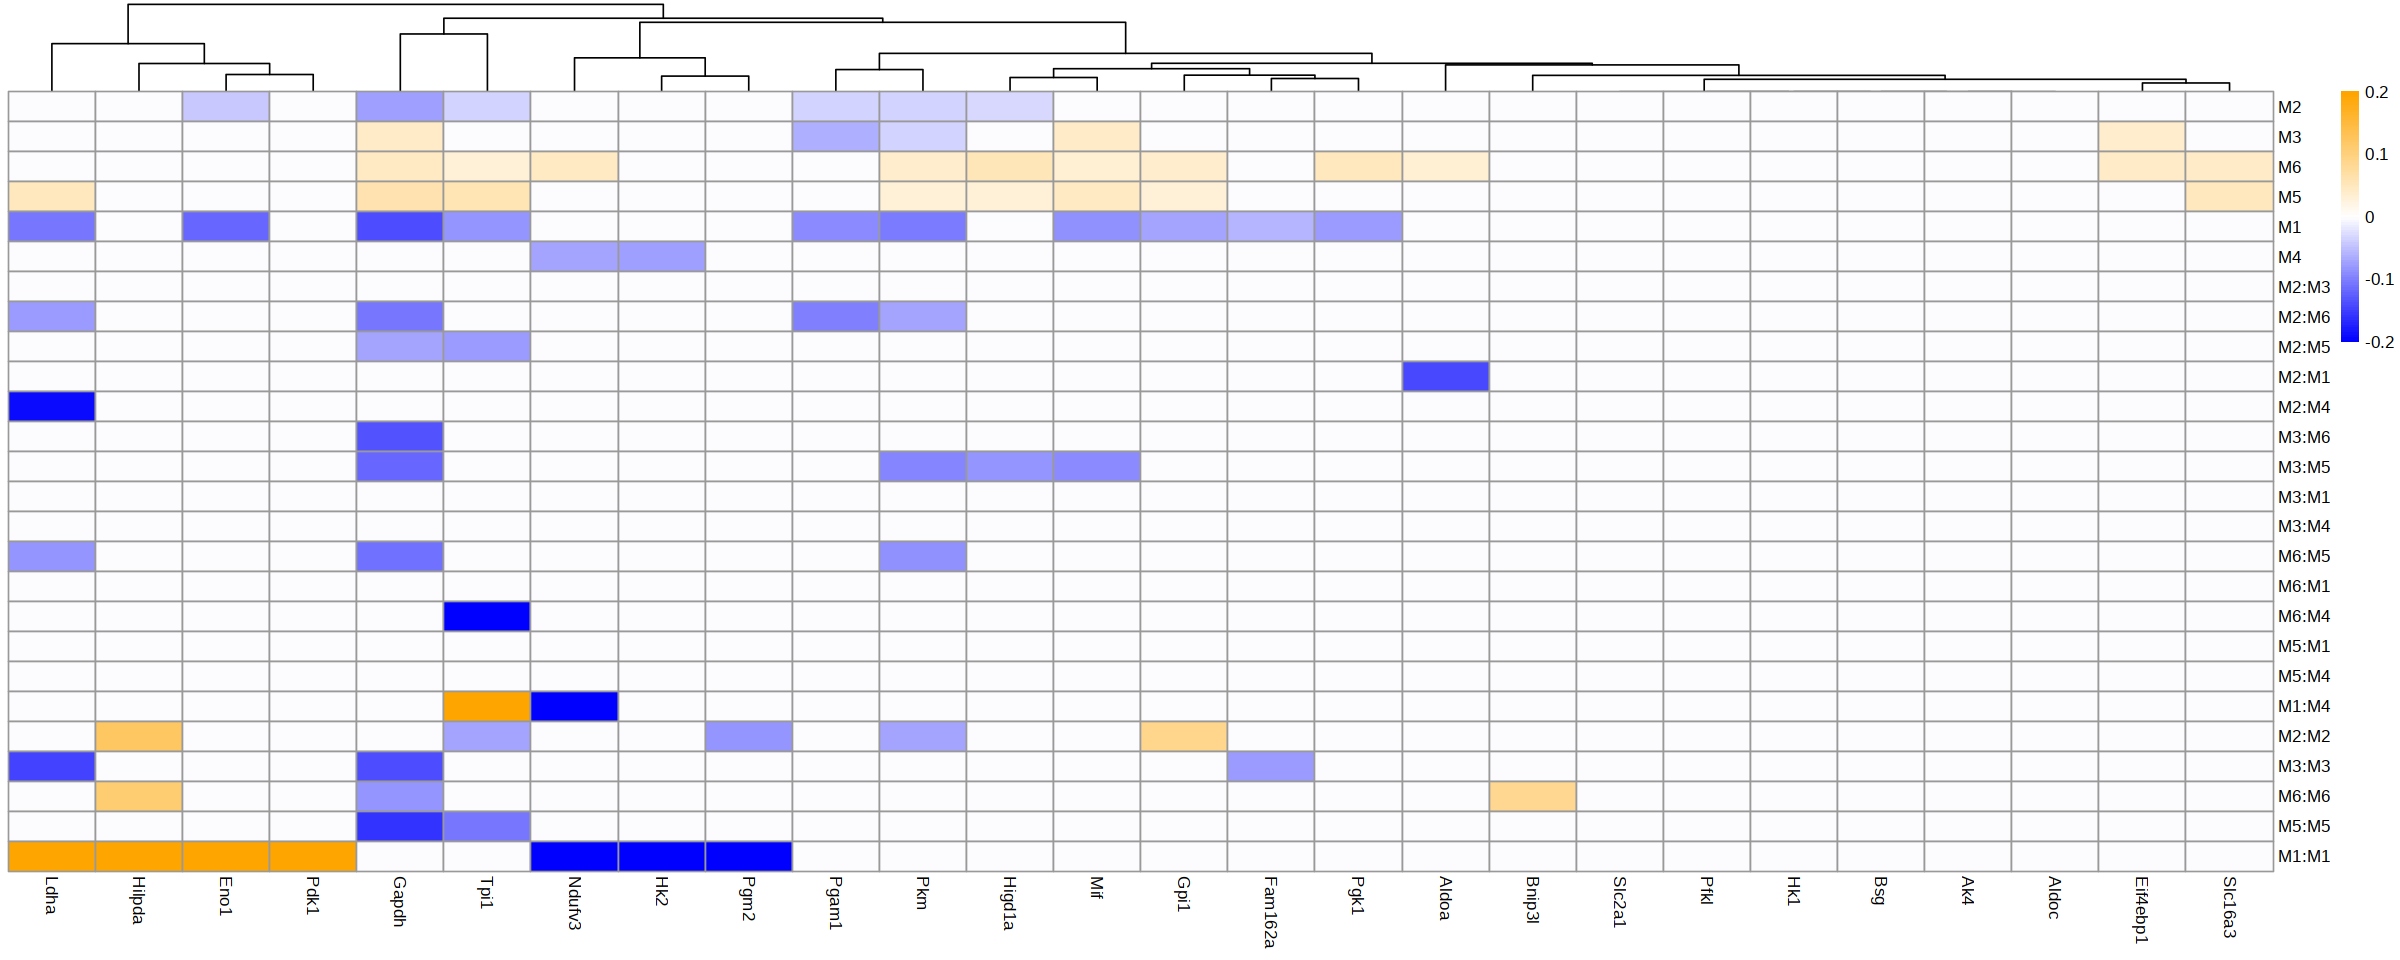

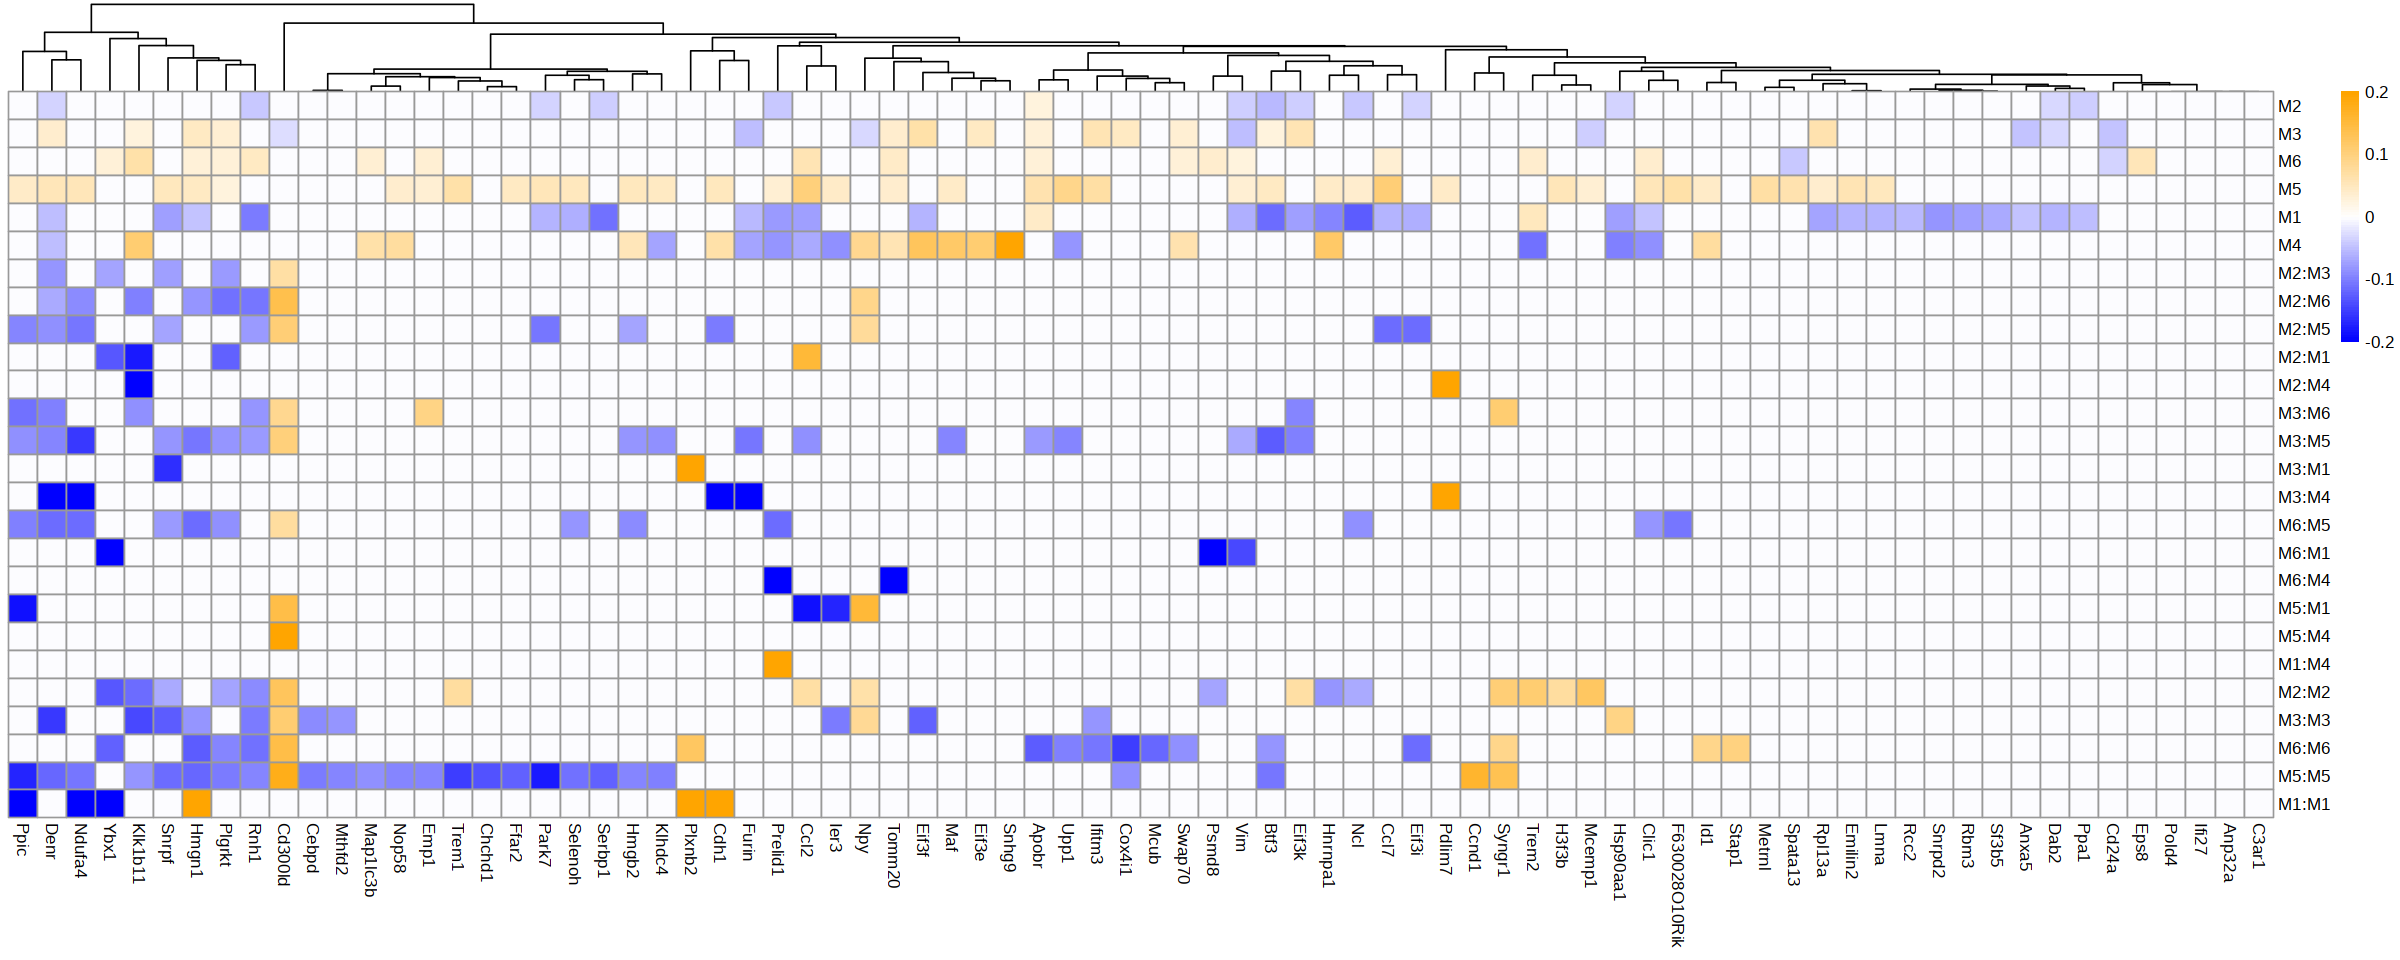

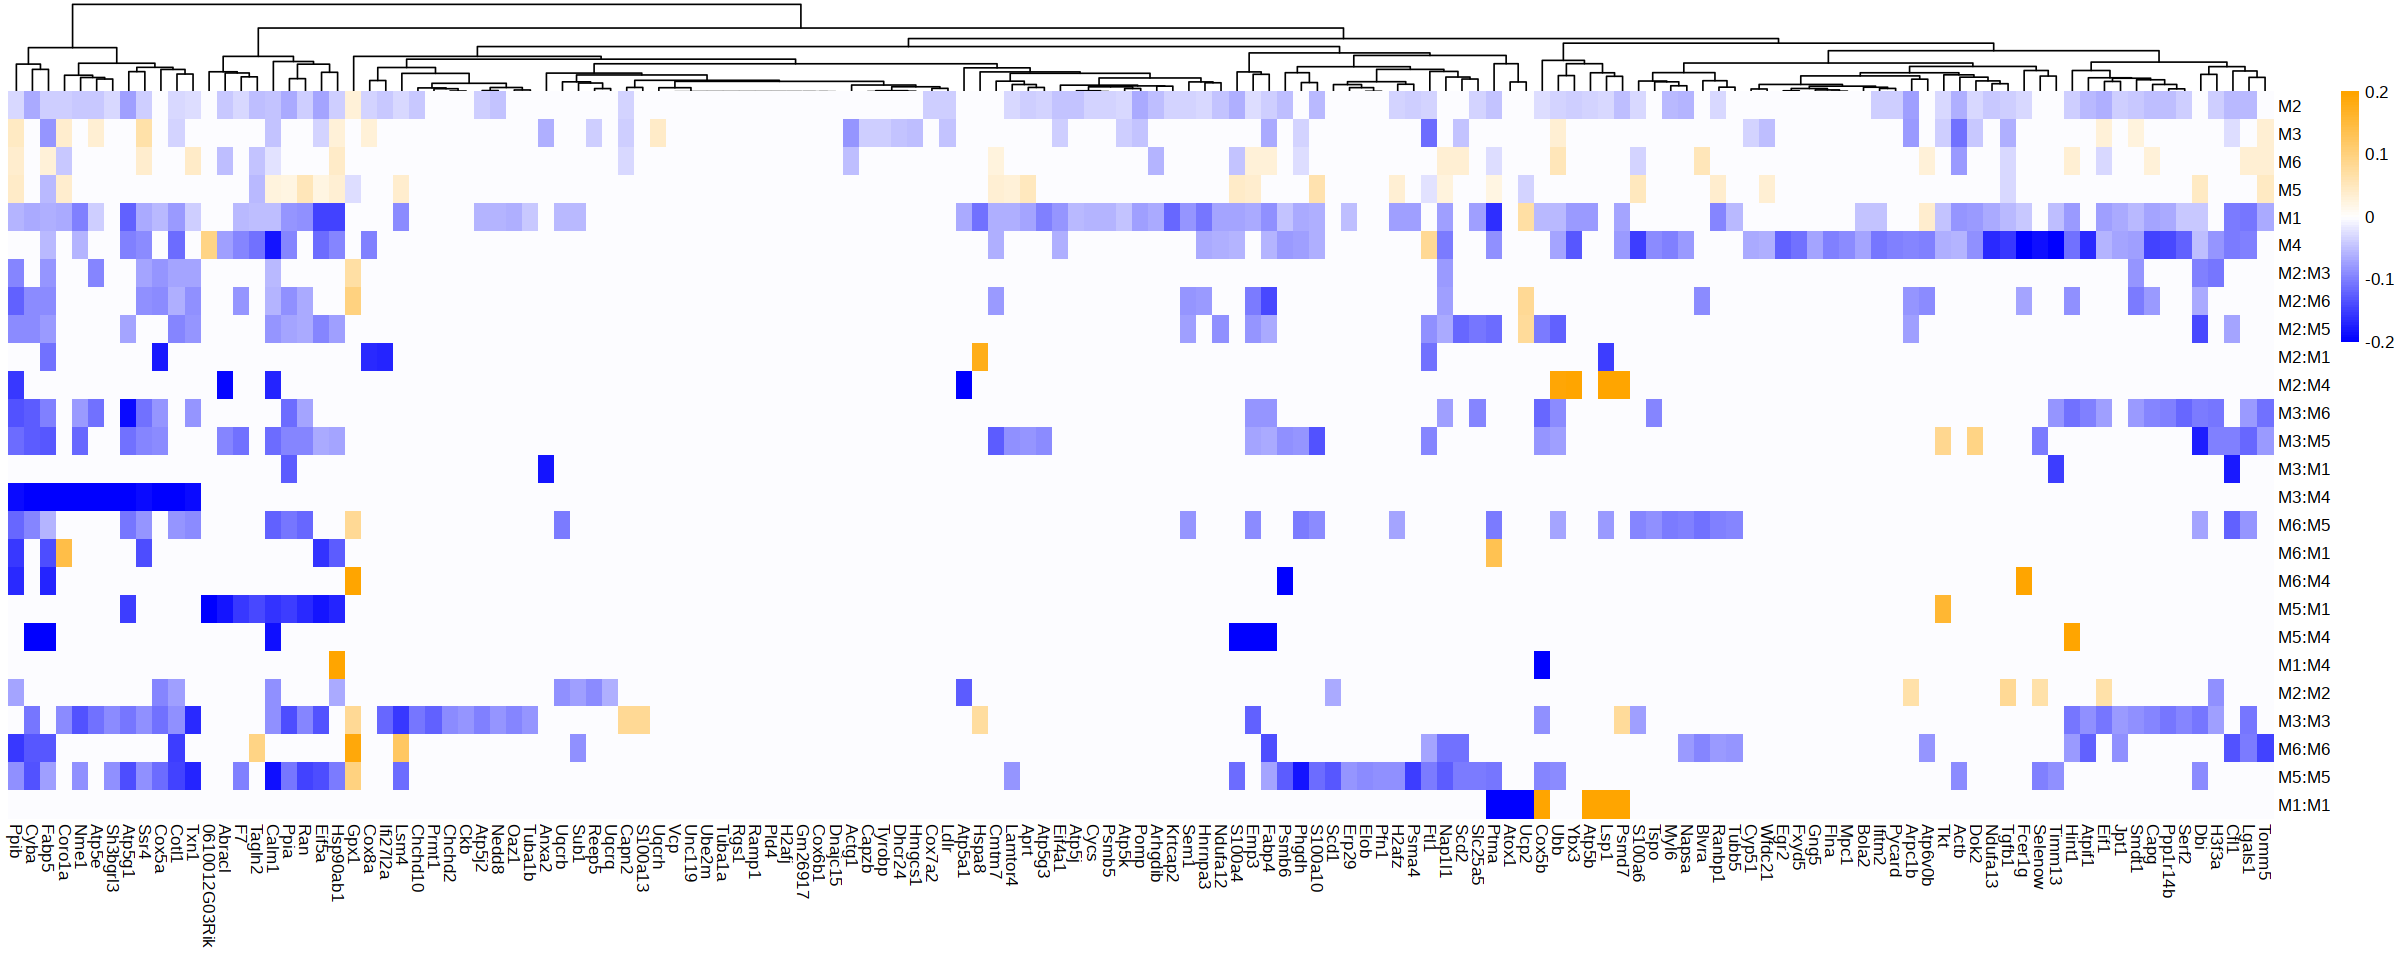

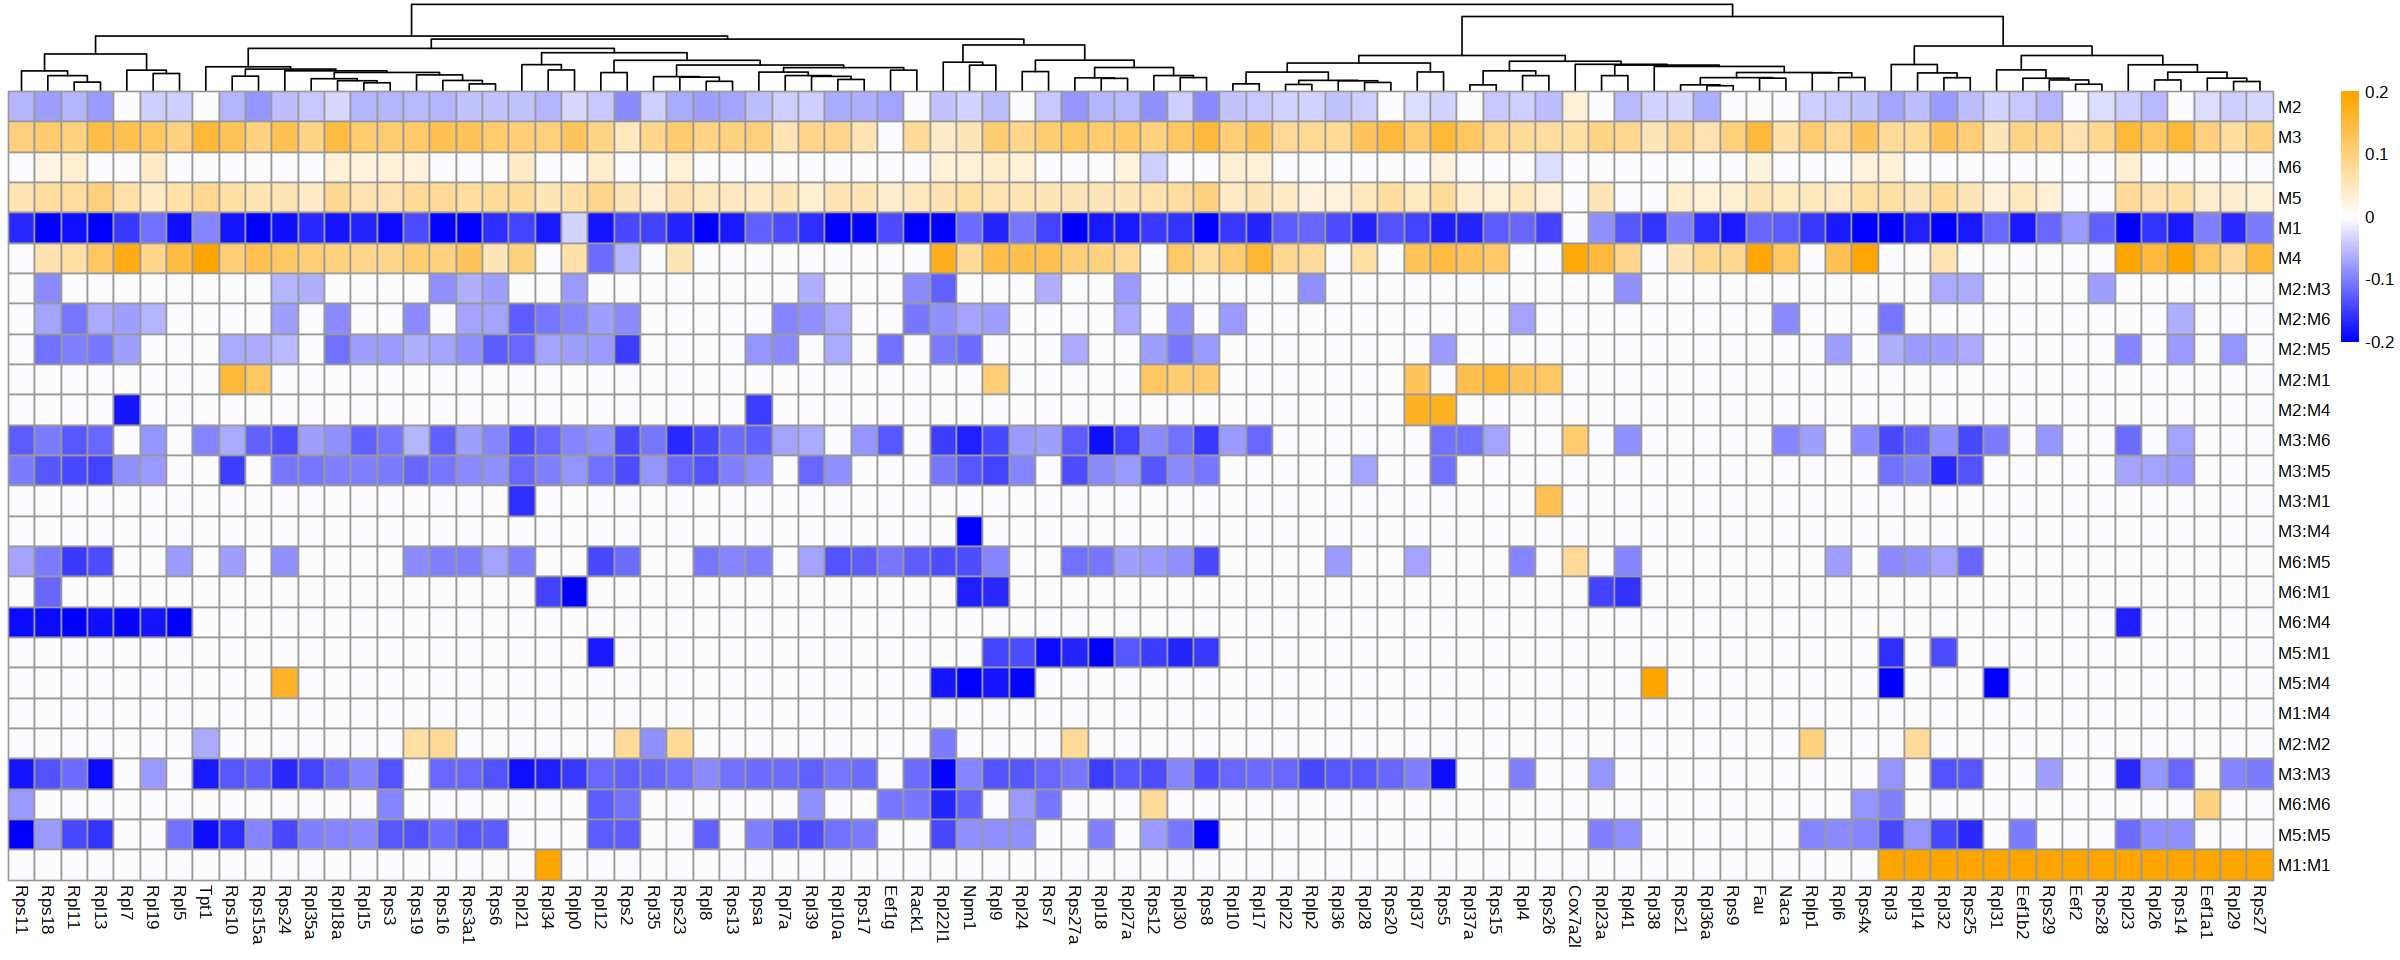

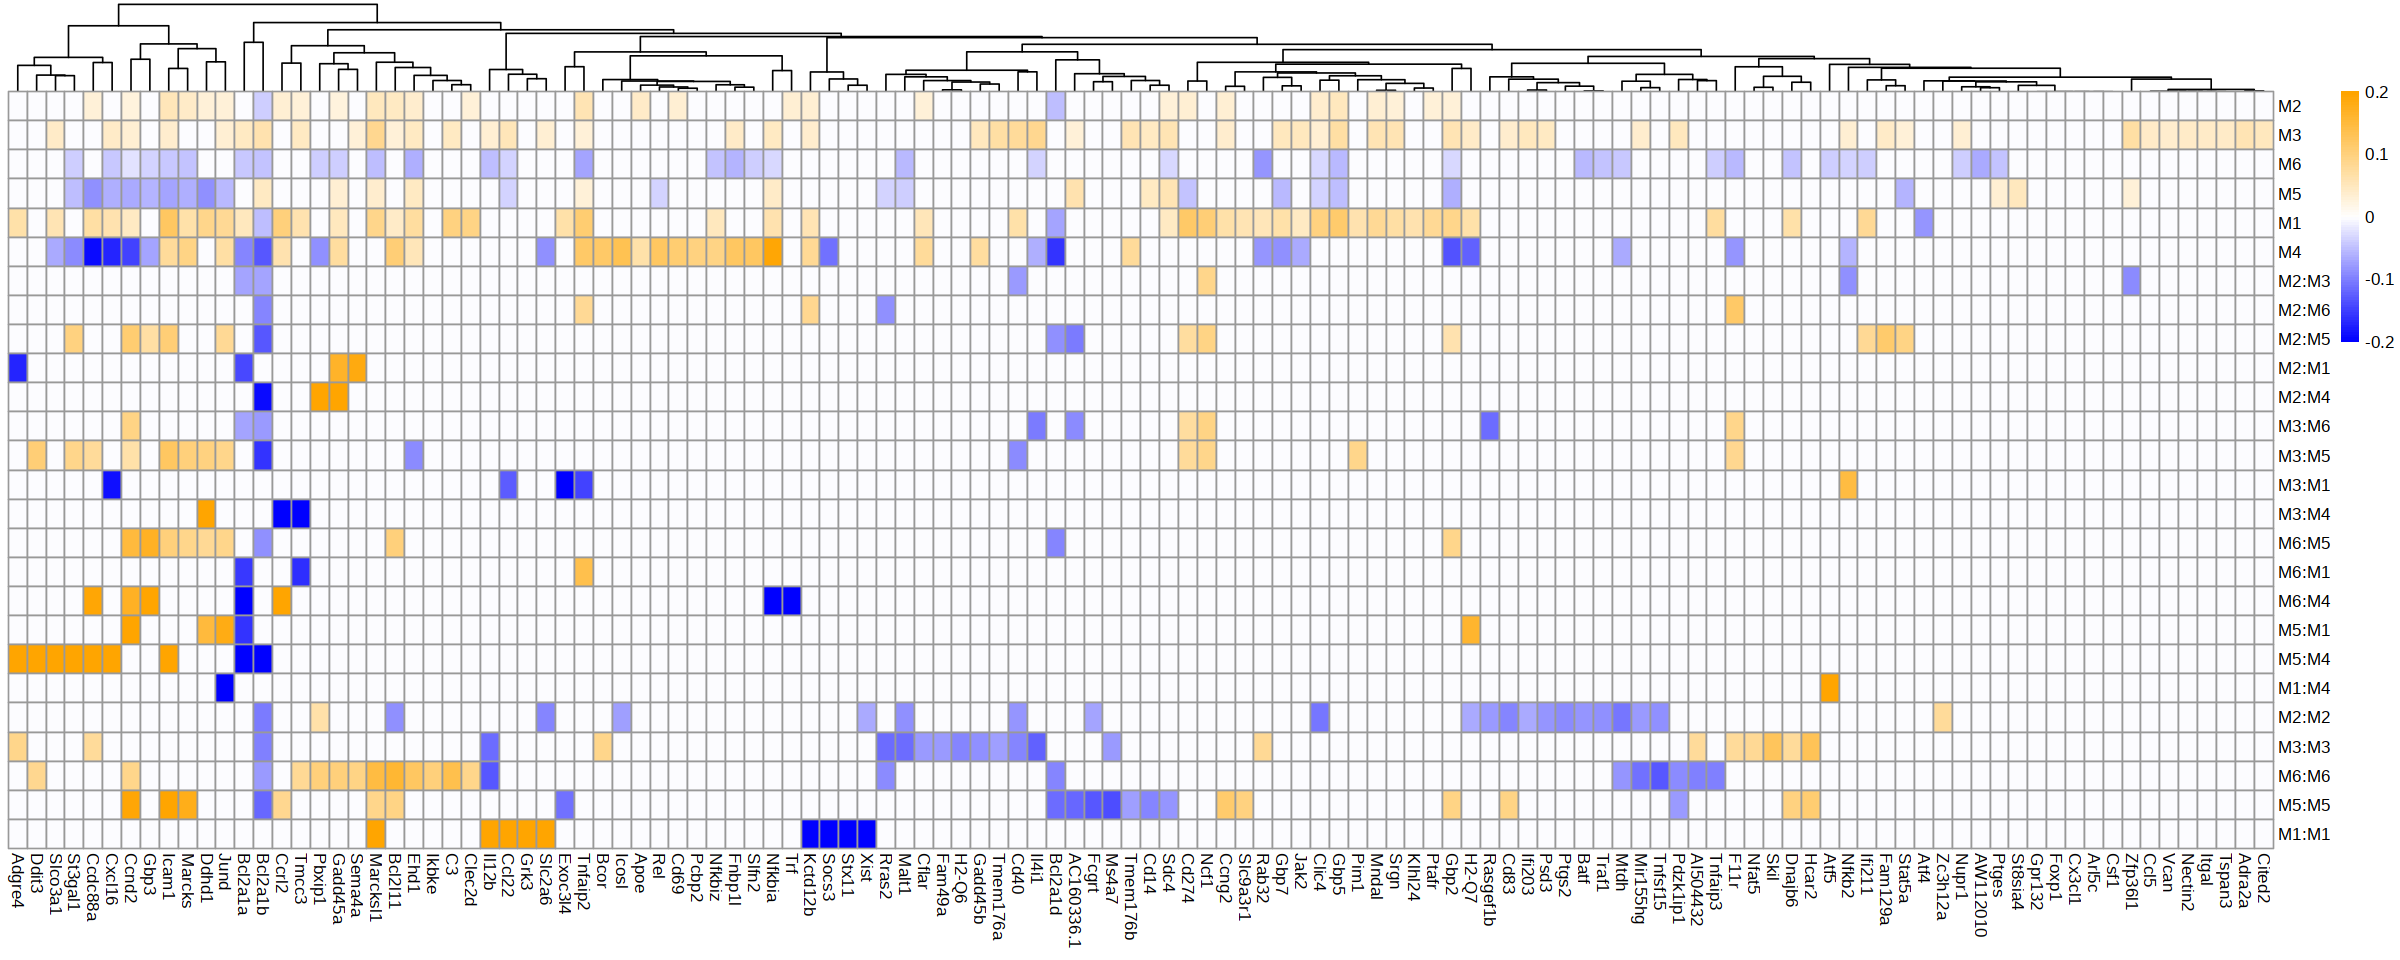

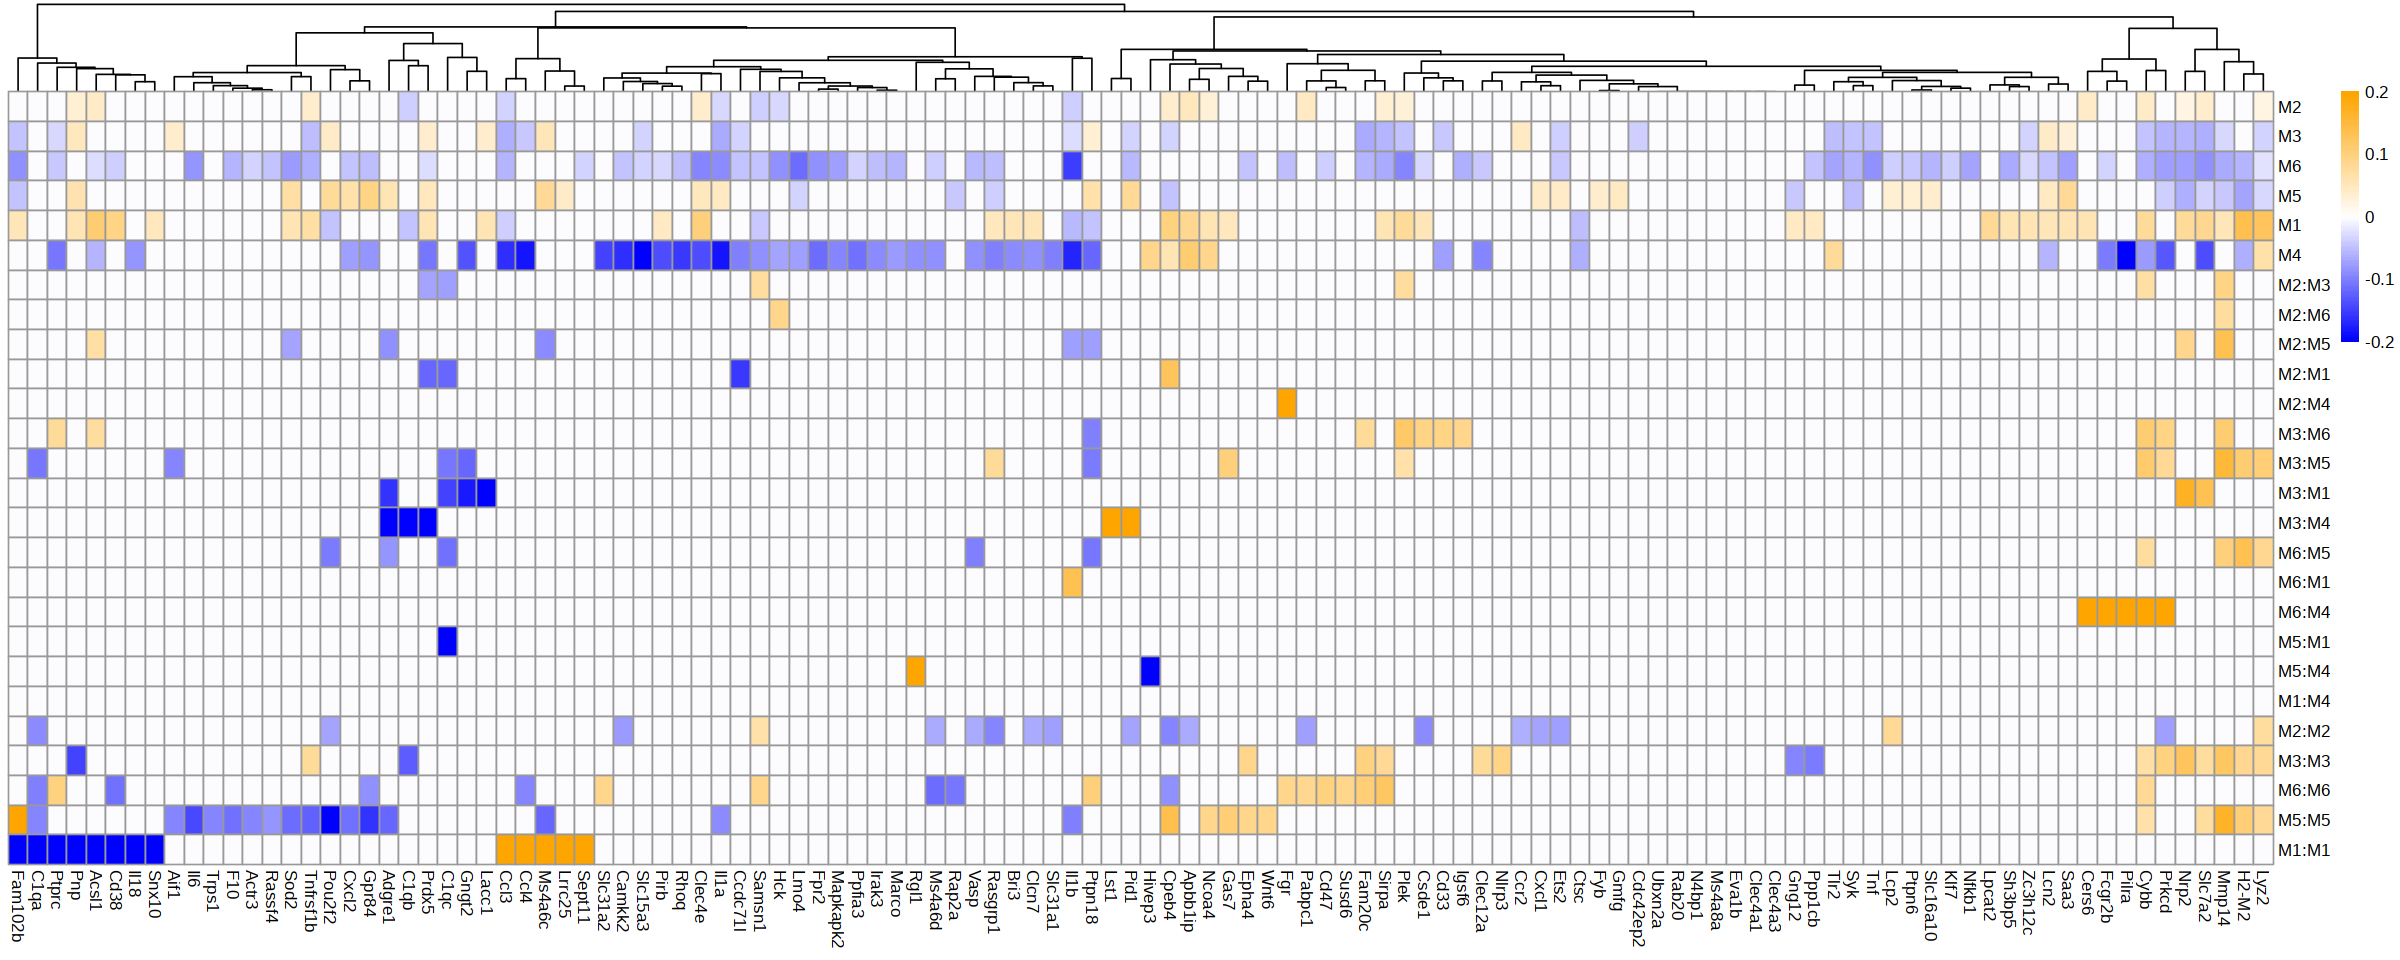

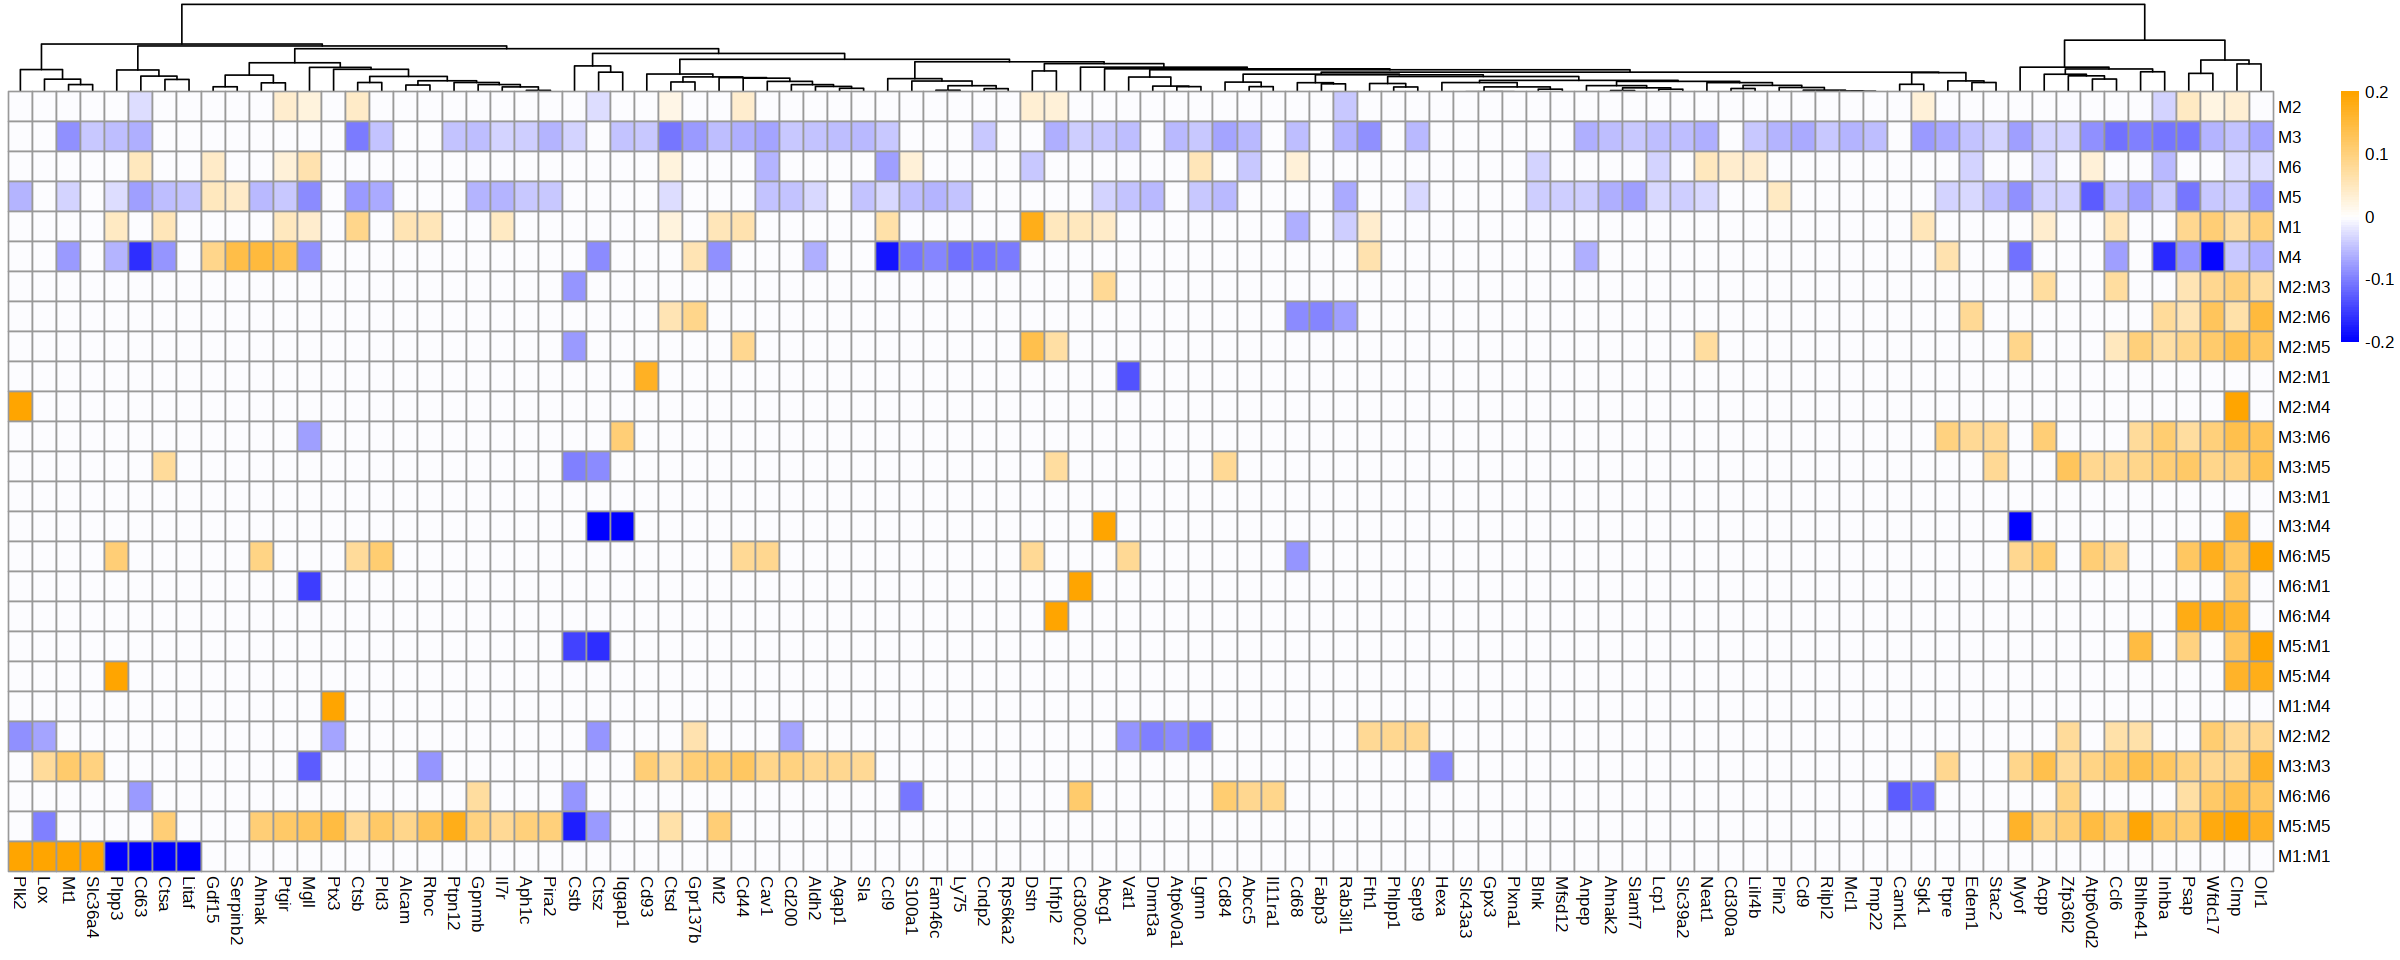

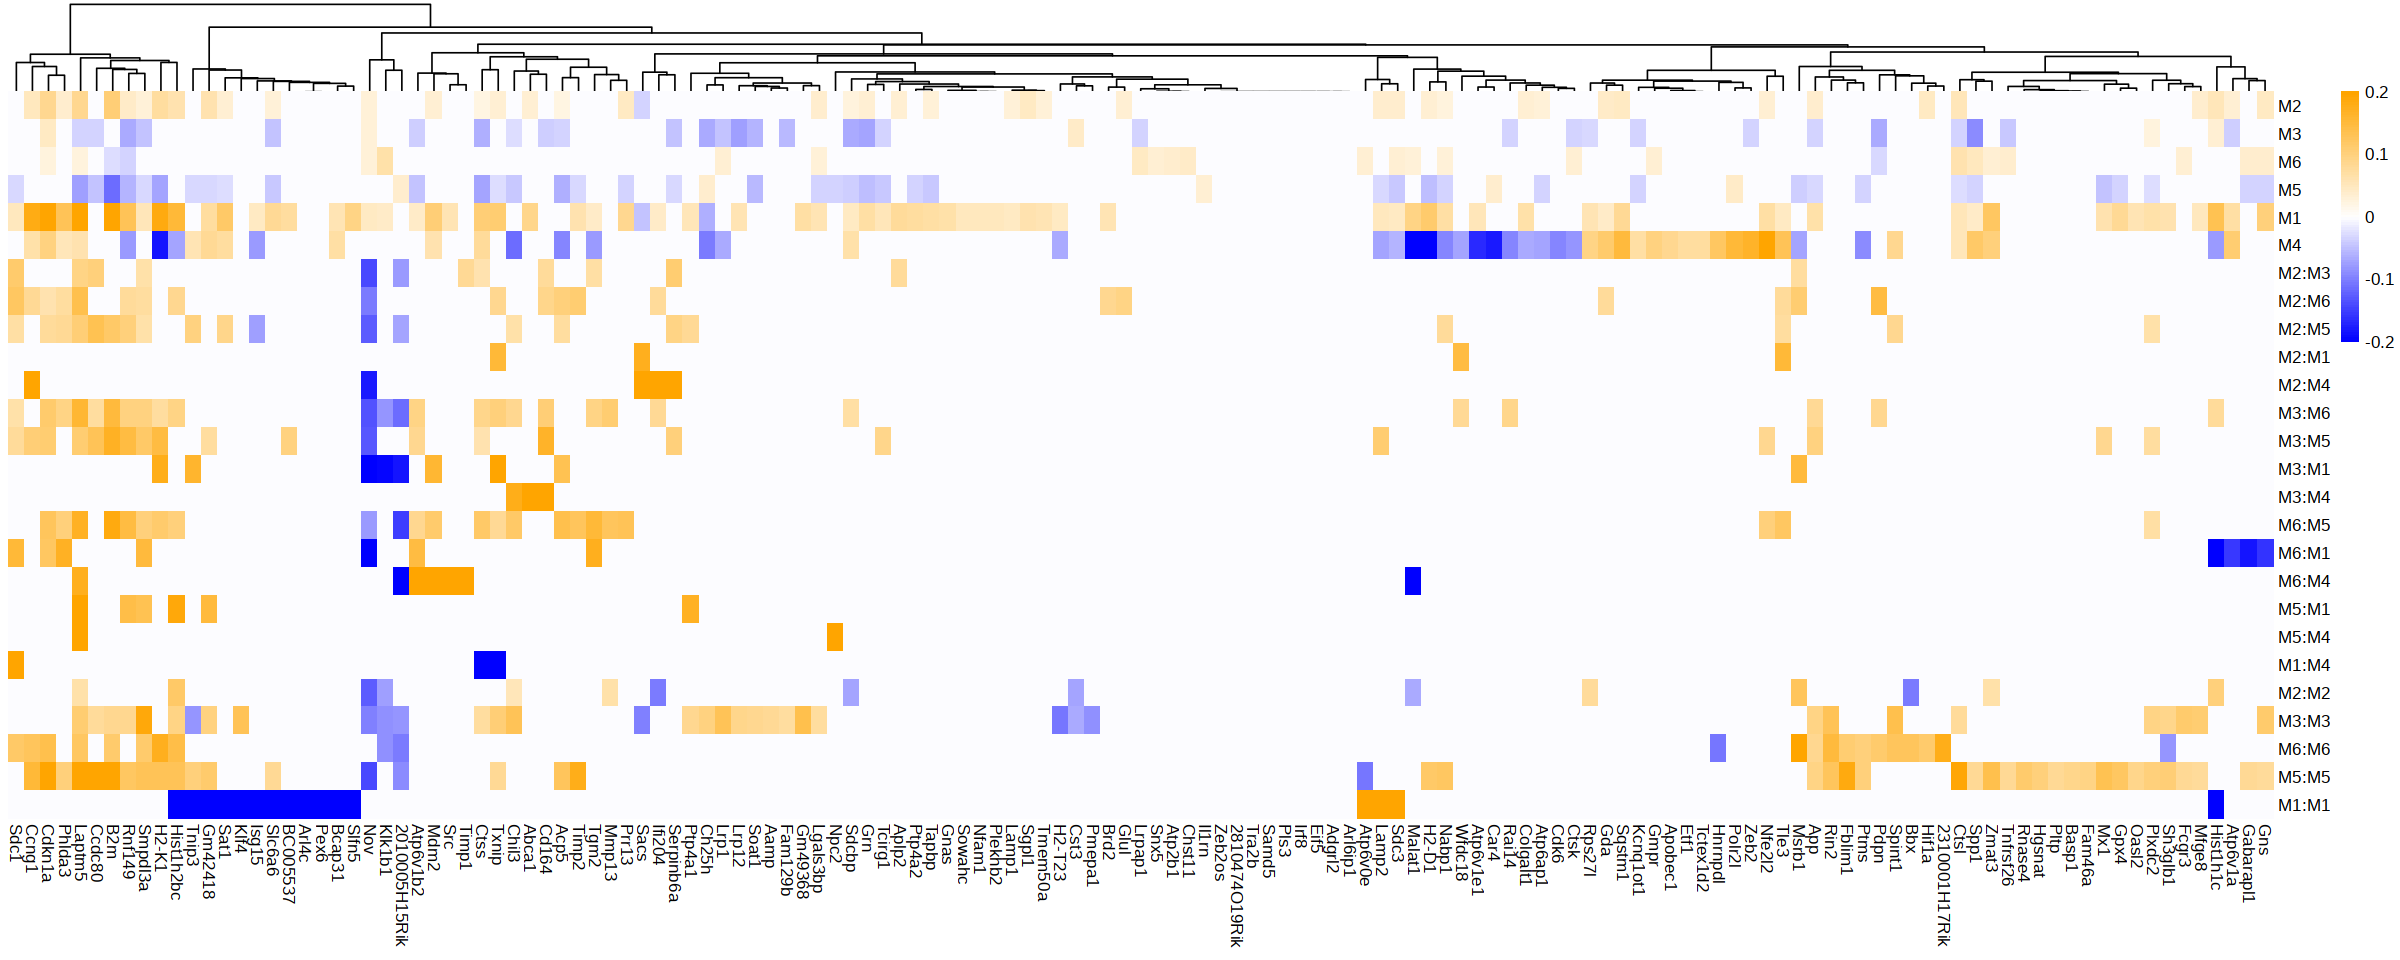

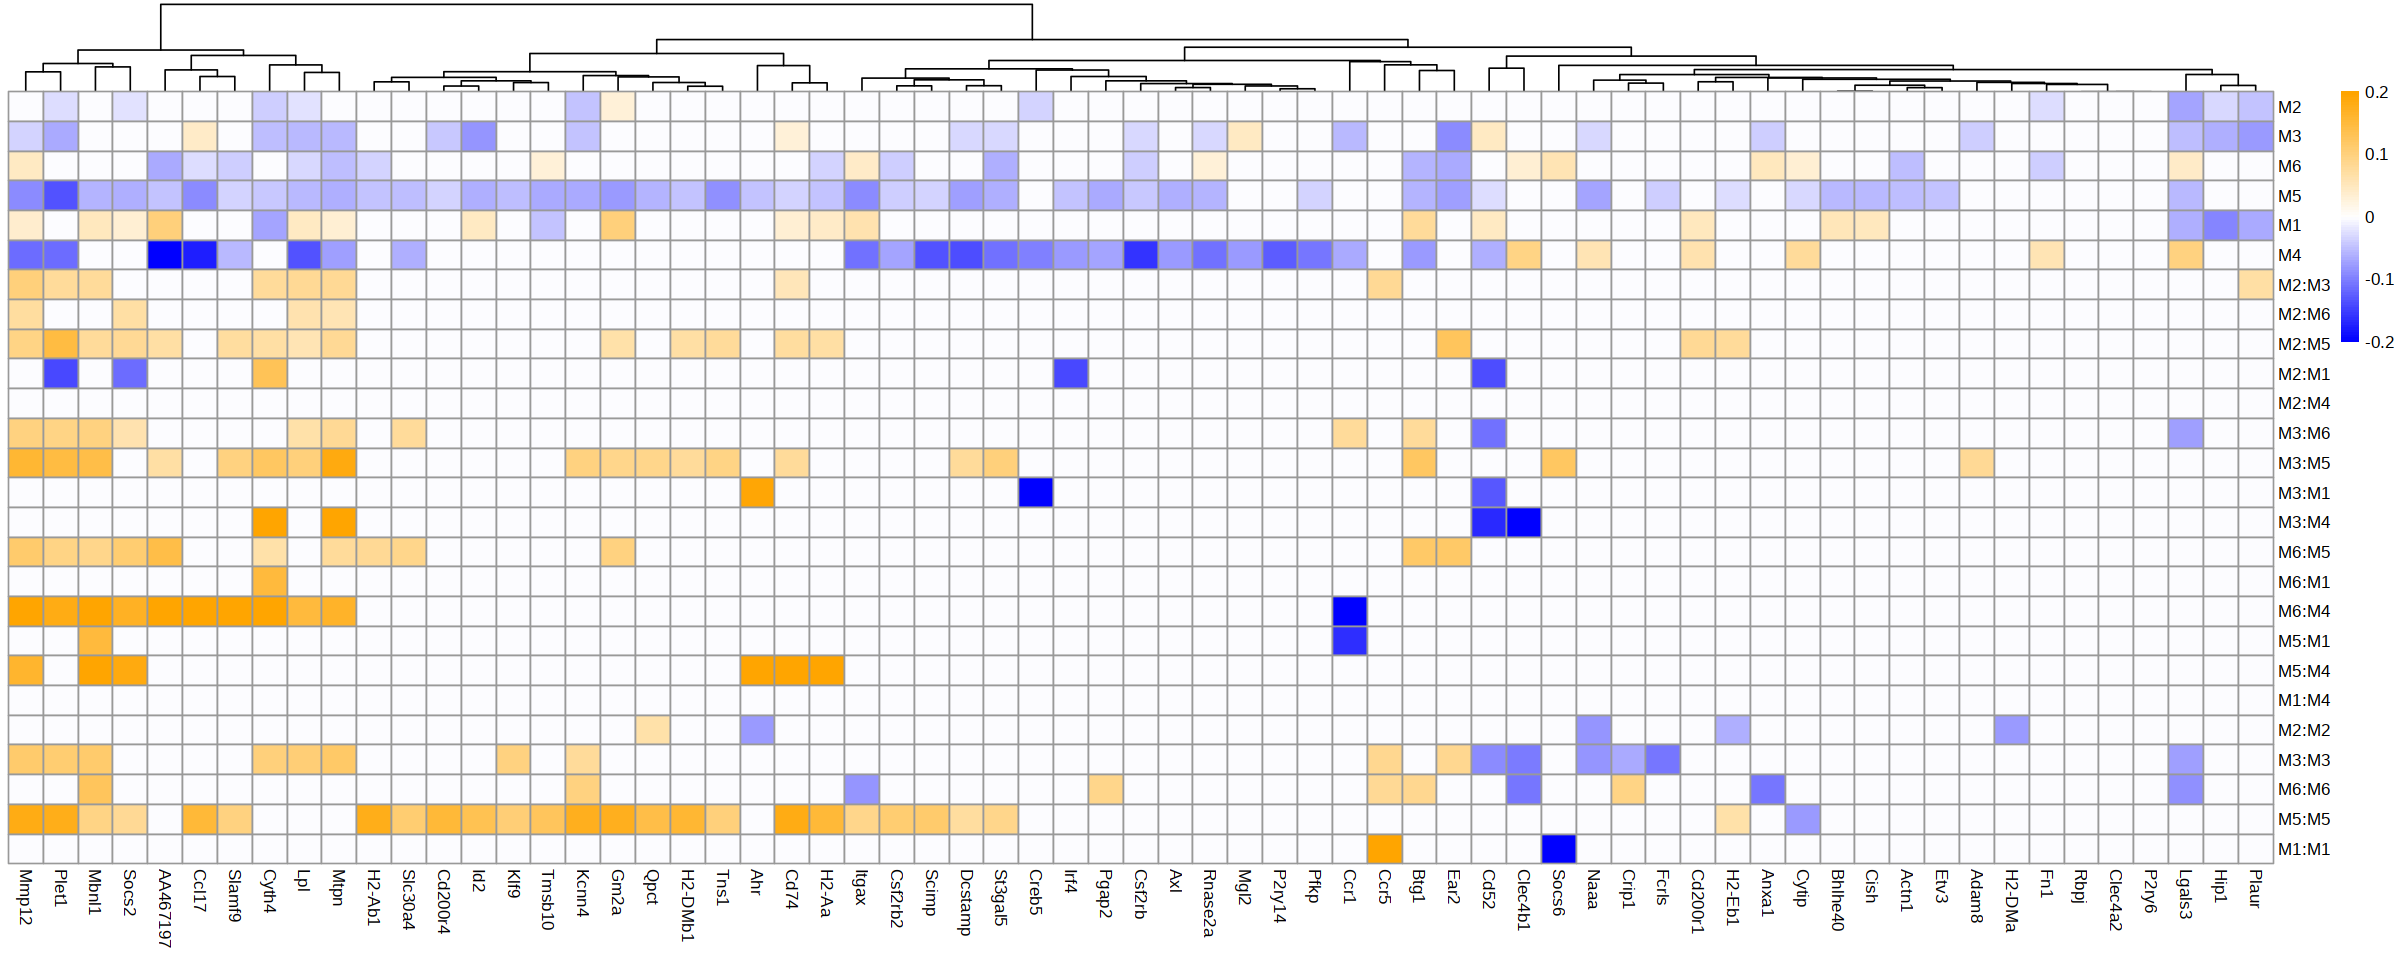

In [7]:
options(repr.plot.width=20, repr.plot.height=8)

allGenesInorder = c()
for (elem in unique(myGeneModules$GeneGroup)){
    aa = combosInterPlot[, rownames(myGeneModules)[myGeneModules$GeneGroup == elem]]
    k = pheatmap(aa,
             cluster_rows = FALSE,
             colorRampPalette(c("blue", "white", "orange"))(100),
             clustering_method="ward.D2")
    
    allGenesInorder = c(allGenesInorder, colnames(aa)[k$tree_col$order])

}


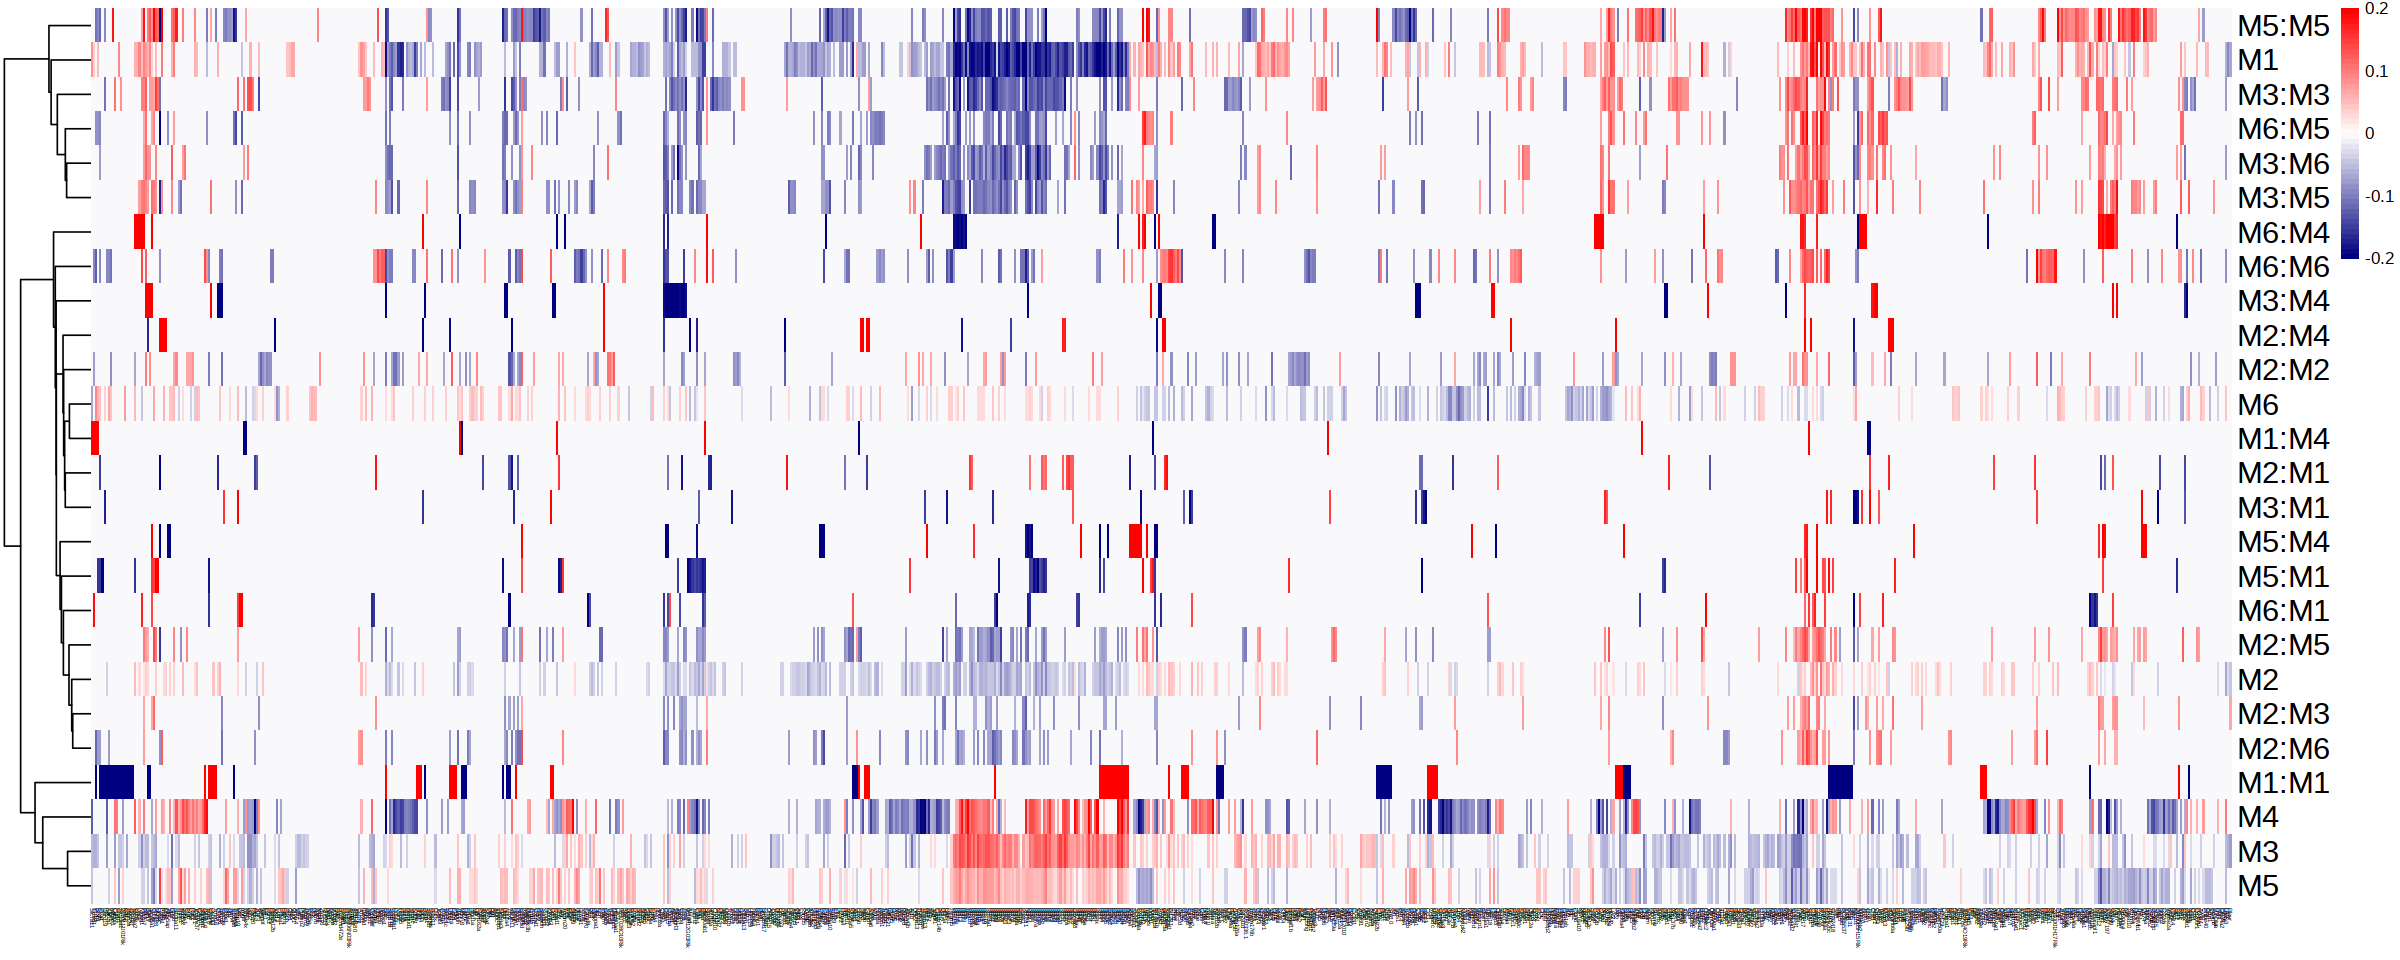

In [8]:
km2 <- pheatmap(combosInterPlot[,allGenesInorder], 
         cluster_cols = FALSE,
         cluster_rows = TRUE,
         clustering_method="ward.D",
         treeheight_col=0,fontsize_col=3,fontsize_row=18,
         colorRampPalette(c("navy", "white", "red"))(50))


agg_record_1515169412 
                    2

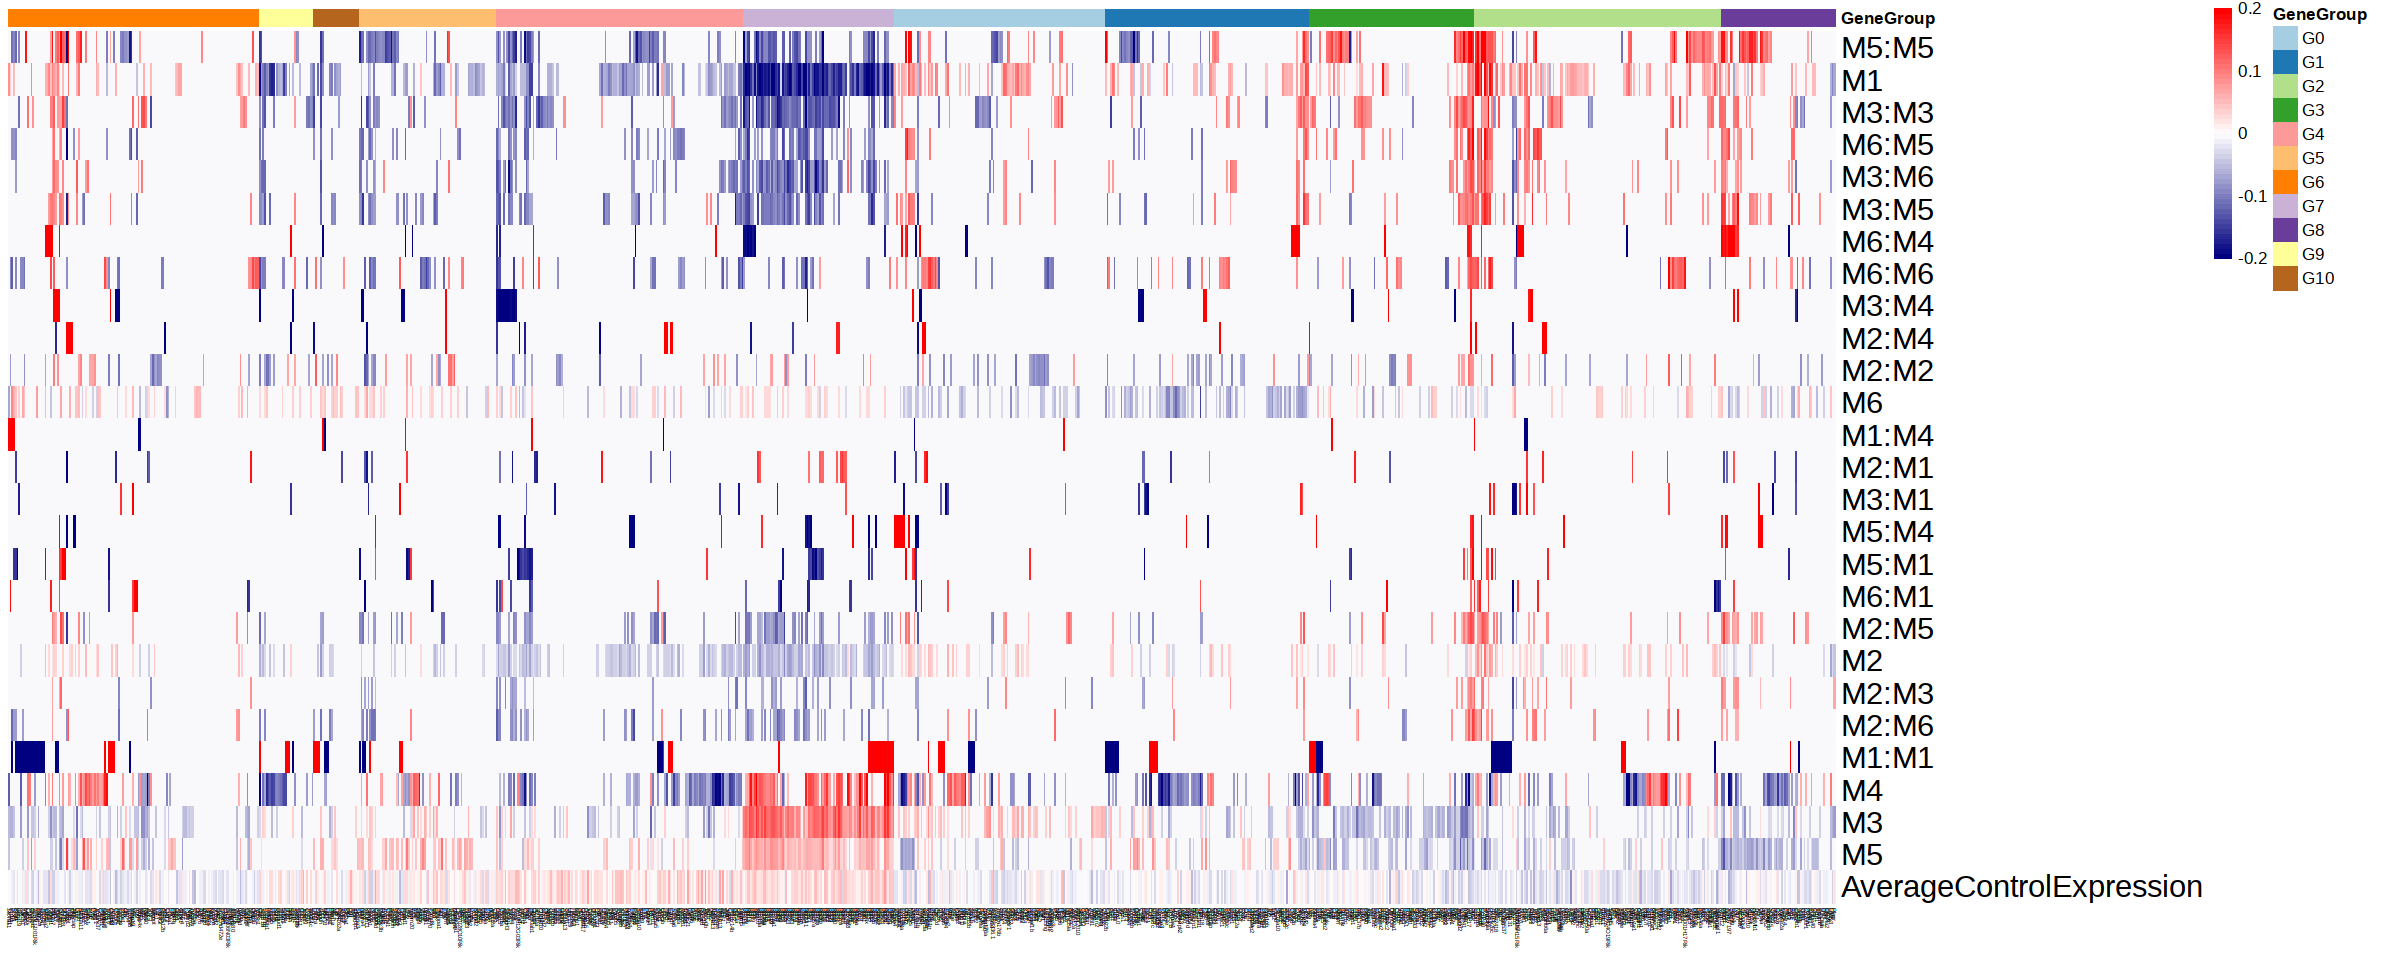

In [9]:

myGeneOrder = allGenesInorder
myrowOrder = rownames(combosInterPlot)[km2$tree_row$order]

cMean1 = cMean1[myGeneOrder,]
combosInterPlot = data.frame(rbind(combosInterPlot,cMean1$MeanExp_Cont2))


combosInterPlot = combosInterPlot[1:27,]
rownames(combosInterPlot) = c(initialRowNames, "AverageControlExpression")

myAnno = myGeneModules[myGeneOrder, , drop = FALSE]

names(combosInterPlot)[names(combosInterPlot) == "X2010111I01Rik"] = "2010111I01Rik"
names(combosInterPlot)[names(combosInterPlot) == "X0610012G03Rik"] = "0610012G03Rik"
names(combosInterPlot)[names(combosInterPlot) == "H2.M2"] = "H2-M2"
names(combosInterPlot)[names(combosInterPlot) == "H2.Q6"] = "H2-Q6"
names(combosInterPlot)[names(combosInterPlot) == "H2.Q7"] = "H2-Q7"
names(combosInterPlot)[names(combosInterPlot) == "H2.D1"] = "H2-D1"
names(combosInterPlot)[names(combosInterPlot) == "H2.K1"] = "H2-K1"
names(combosInterPlot)[names(combosInterPlot) == "H2.T23"] = "H2-T23"
names(combosInterPlot)[names(combosInterPlot) == "X2010005H15Rik"] = "2010005H15Rik"
names(combosInterPlot)[names(combosInterPlot) == "X2310001H17Rik"] = "2310001H17Rik"
names(combosInterPlot)[names(combosInterPlot) == "X2810474O19Rik"] = "2810474O19Rik"
names(combosInterPlot)[names(combosInterPlot) == "H2.Aa"] = "H2-Aa"
names(combosInterPlot)[names(combosInterPlot) == "H2.Ab1"] = "H2-Ab1"
names(combosInterPlot)[names(combosInterPlot) == "H2.DMa"] = "H2-DMa"
names(combosInterPlot)[names(combosInterPlot) == "H2.DMb1"] = "H2-DMb1"
names(combosInterPlot)[names(combosInterPlot) == "H2.Eb1"] = "H2-Eb1"

xx <- pheatmap(combosInterPlot[c(myrowOrder,"AverageControlExpression"), myGeneOrder], 
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         clustering_method="ward.D",
         treeheight_col=0,fontsize_col=3,fontsize_row=18,
         annotation_col = myAnno,
         annotation_colors = annoCols,
         colorRampPalette(c("navy", "white", "red"))(50))

save_pheatmap_pdf(xx, "figures/Figure_5D.pdf", width=20, height=8)

In [10]:
write.csv(combosInterPlot[c(myrowOrder,"AverageControlExpression"), myGeneOrder], "outputs/Fig_5D.csv")

In [11]:
myInsignGenes = sapply(combosInter, function(x){length(which(x == 0))})

kk = data.frame(GroupNames=names(myInsignGenes), Insignificant = myInsignGenes)
kk$Significant = 1041 - kk$Insignificant
kk = melt(kk, id.vars="GroupNames")
kk$GroupNames = factor(kk$GroupNames, levels = colnames(combosInter))
# The original relabelled after setting levels, which dropped them and left
# ggplot to sort the displayed strings; that order is reproduced here.
publishedOrder <- order(gsub("_", "", colnames(combosInter)))
kk$GroupNames  <- factor(moduleLabel(as.character(kk$GroupNames)),
                         levels = moduleLabel(colnames(combosInter))[publishedOrder])

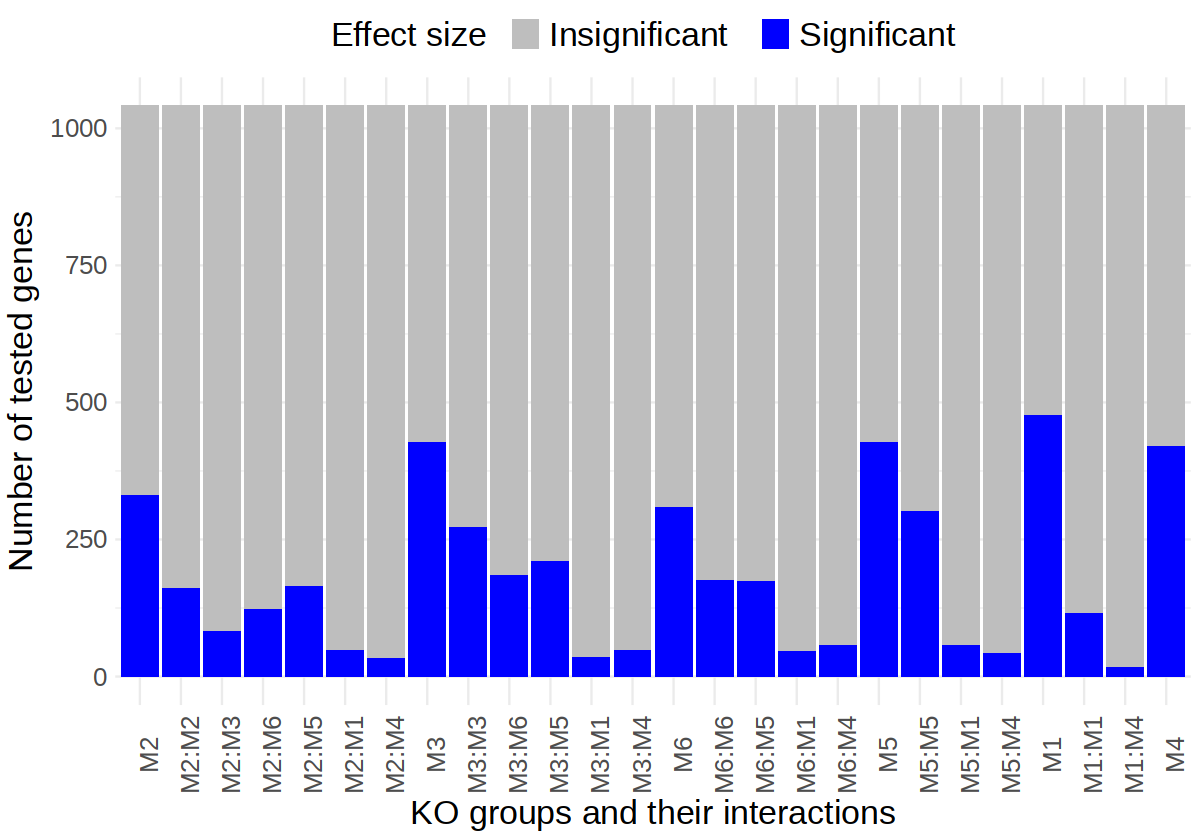

In [12]:
options(repr.plot.width=10, repr.plot.height=7)

#pdf("./../SupplementaryFigures/S_6C.pdf", width=12, height=6)
ggplot(kk, aes(fill=variable, y=value, x=GroupNames)) + 
    geom_bar(position="stack", stat="identity")+
    scale_fill_manual("Effect size",values=c("grey","blue"))+
    ylab("Number of tested genes")+theme_minimal()+
     theme(axis.text.y = element_text(size = 15),
           axis.text.x = element_text(size = 15, angle=90),
              axis.title = element_text(size = 20),
              strip.text = element_text(size = 25),
              legend.text=element_text(size=20),
              legend.title=element_text(size=20),
              legend.position="top")+xlab("KO groups and their interactions")
#dev.off()

In [13]:
combosInteractionsOnly = combosInter[,colnames(combosInter) %ni% 
                                     c("K_0", "K_1", "K_2", "K_3", "K_4", "K_5")]

combosInteractionsOnly_interMod = combosInteractionsOnly[,colnames(combosInteractionsOnly)[colnames(combosInteractionsOnly) %ni% c("K0:K0", 
                                                                                                                                   "K1:K1",
                                                                                                                                   "K2:K2",
                                                                                                                                   "K3:K3",
                                                                                                                                   "K4:K4")]]
combosInteractionsOnly_intraMod = combosInteractionsOnly[,c("K0:K0", "K1:K1","K2:K2","K3:K3","K4:K4")]

sgnInterModInteractions = apply(combosInteractionsOnly_interMod,1, 
                                function(x){length(which(x != 0))})
sgnIntraModInteractions = apply(combosInteractionsOnly_intraMod,1, 
                                function(x){length(which(x != 0))})

kk = data.frame(GroupNames=names(sgnInterModInteractions), 
                InterModule_Significant = sgnInterModInteractions,
                IntraModule_Significant = sgnIntraModInteractions)
kk$InSignificant = 20 - (sgnInterModInteractions + sgnIntraModInteractions)
kk = kk[order(-kk$InSignificant, -kk$IntraModule_Significant, -kk$InterModule_Significant),]
kk = melt(kk, id.vars="GroupNames")
kk$GroupNames = factor(kk$GroupNames, levels=kk$GroupNames[1:1041])
kk

GroupNames,variable,value
<fct>,<fct>,<dbl>
AI314180,InterModule_Significant,0
Abcc1,InterModule_Significant,0
Ampd3,InterModule_Significant,0
Anxa3,InterModule_Significant,0
Anxa4,InterModule_Significant,0
Ass1,InterModule_Significant,0
B430306N03Rik,InterModule_Significant,0
Chpf2,InterModule_Significant,0
Ckap4,InterModule_Significant,0


Suplementary Figure 9F

In [14]:
options(repr.plot.width=15, repr.plot.height=7)

pdf("figures/Figure_S6B.pdf", width=20, height=8)
ggplot(kk, aes(fill=variable, y=value, x=GroupNames)) + 
    geom_bar(position="stack", stat="identity")+
    scale_fill_manual("Effect size",values=c("orange", "red", "grey"))+
    ylab("Number of interaction terms")+theme_minimal()+
     theme(axis.text.y = element_text(size = 15),
           axis.text.x = element_text(size = 2, angle=90),
              axis.title = element_text(size = 20),
              strip.text = element_text(size = 25),
              legend.text=element_text(size=20),
              legend.title=element_text(size=20),
              legend.position="top")+xlab("Genes")

dev.off()

agg_record_1924367936 
                    2

In [15]:
combosInterMyTemp = combosInter[,colnames(combosInter) %ni% c("K_0", "K_1", "K_2", "K_3", "K_4", "K_5")]
combosInterMyTemp$Gene =rownames(combosInterMyTemp)
combosInterMelt = melt(combosInterMyTemp, id.vars="Gene")
combosInterMelt = combosInterMelt[combosInterMelt$value != 0,]
combosInterMelt$Group1 = sapply(combosInterMelt$variable, 
                                function(x){strsplit(as.character(x),":")[[1]][1]})
combosInterMelt$Group2 = sapply(combosInterMelt$variable, 
                                function(x){strsplit(as.character(x),":")[[1]][2]})
combosInterMelt$GeneGroup1 = paste0(combosInterMelt$Gene,"_",combosInterMelt$Group1)
combosInterMelt$GeneGroup2 = paste0(combosInterMelt$Gene,"_",combosInterMelt$Group2)

In [16]:
combosInterMyTemp_2 = combosInter[,colnames(combosInter) %in% c("K_0", "K_1", "K_2", "K_3", "K_4", "K_5")]
combosInterMyTemp_2$Gene =rownames(combosInterMyTemp_2)
combosInterMelt_2 = melt(combosInterMyTemp_2, id.vars="Gene")
combosInterMelt_2$GeneGroup = paste0(combosInterMelt_2$Gene,"_",combosInterMelt_2$variable)
combosInterMelt_2 = combosInterMelt_2[,c("GeneGroup", "value")]

combosInterMelt_21 = copy(combosInterMelt_2)
colnames(combosInterMelt_21) = c("GeneGroup1", 
                                 "Group1Value")
combosInterMelt_22 = copy(combosInterMelt_2)
colnames(combosInterMelt_22) = c("GeneGroup2", 
                                 "Group2Value")

head(combosInterMelt_21)

,GeneGroup1,Group1Value
,<chr>,<dbl>
1,AI314180_K_0,0.00000000
2,Abcc1_K_0,0.00000000
3,Acod1_K_0,0.03162562
4,Akr1a1_K_0,0.00000000
5,Alas1_K_0,0.00000000
6,Alox5ap_K_0,0.00000000


In [17]:
combosInterMelt = merge(combosInterMelt, combosInterMelt_21, by="GeneGroup1")
combosInterMelt = merge(combosInterMelt, combosInterMelt_22, by="GeneGroup2")
combosInterMelt = combosInterMelt[order(combosInterMelt$Group1, combosInterMelt$Group2, 
                                        combosInterMelt$Group1Value, combosInterMelt$Group2Value, combosInterMelt$value),]

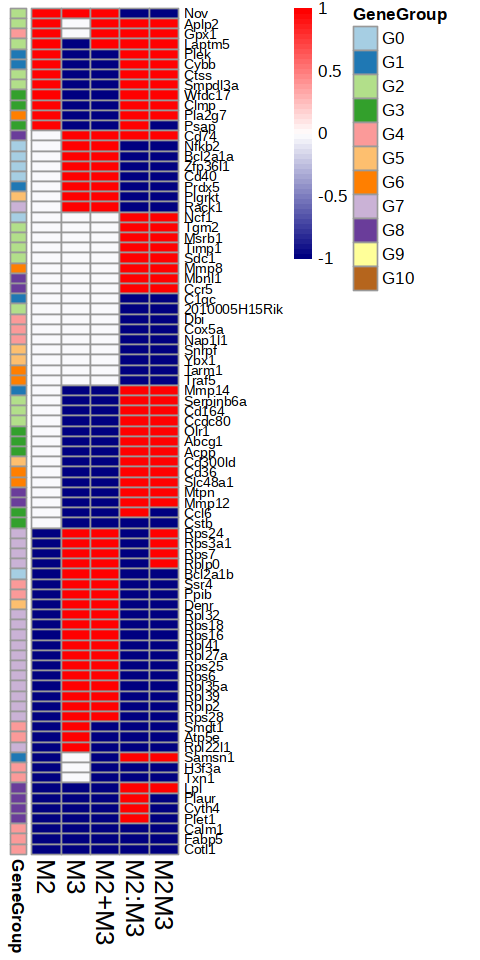

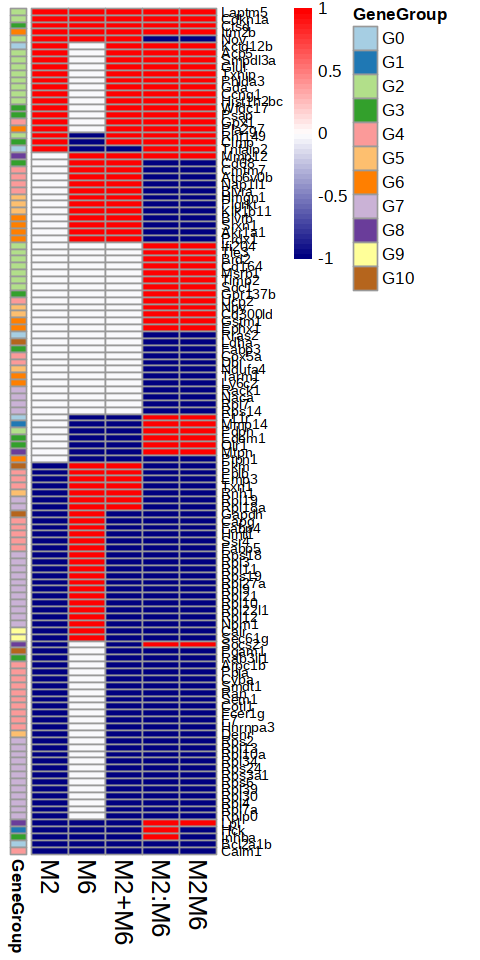

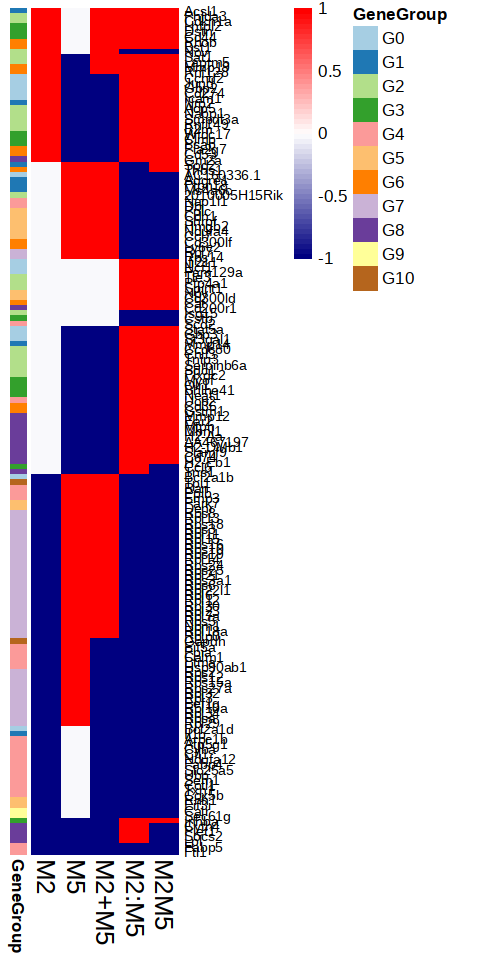

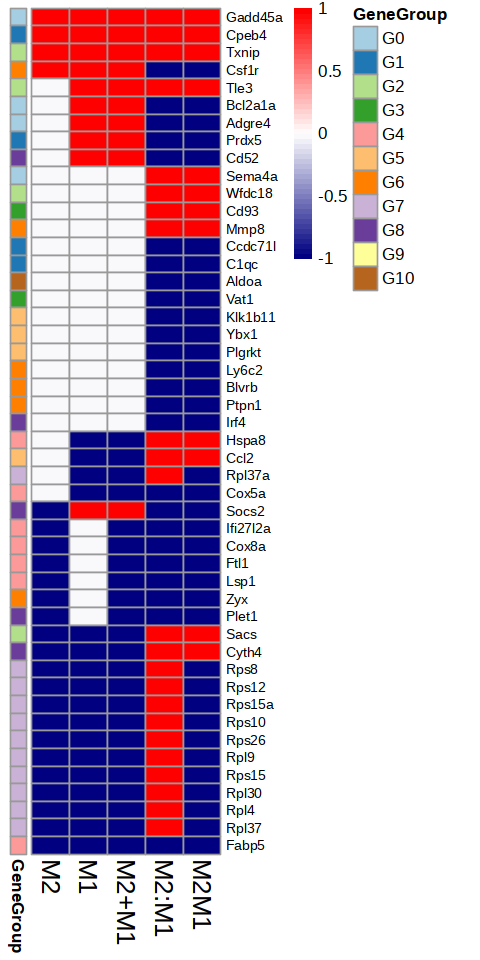

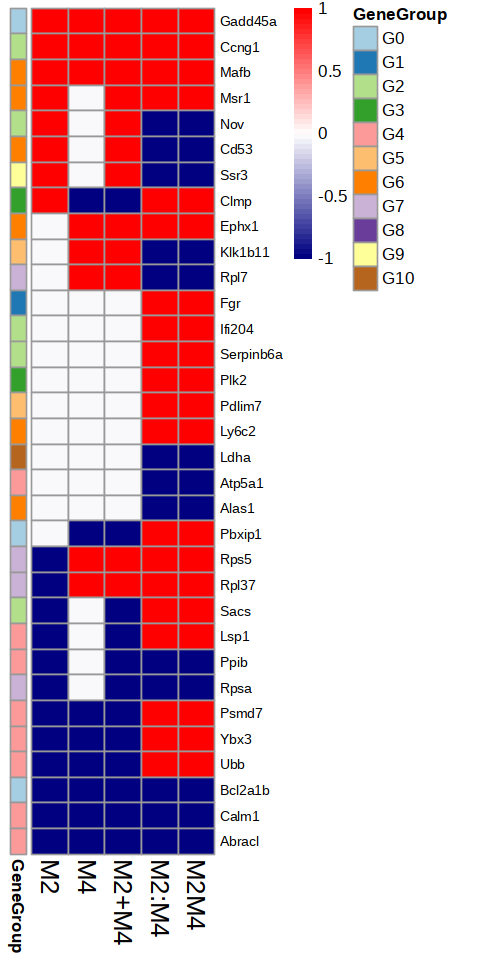

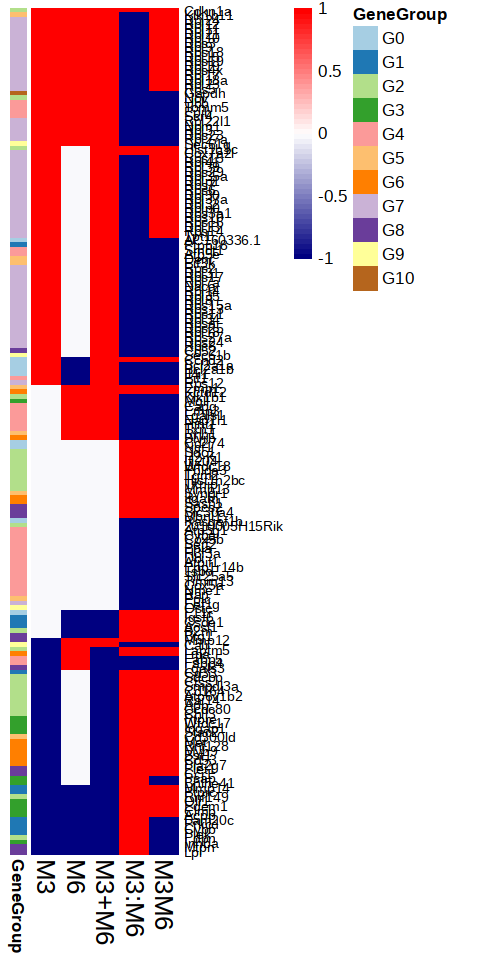

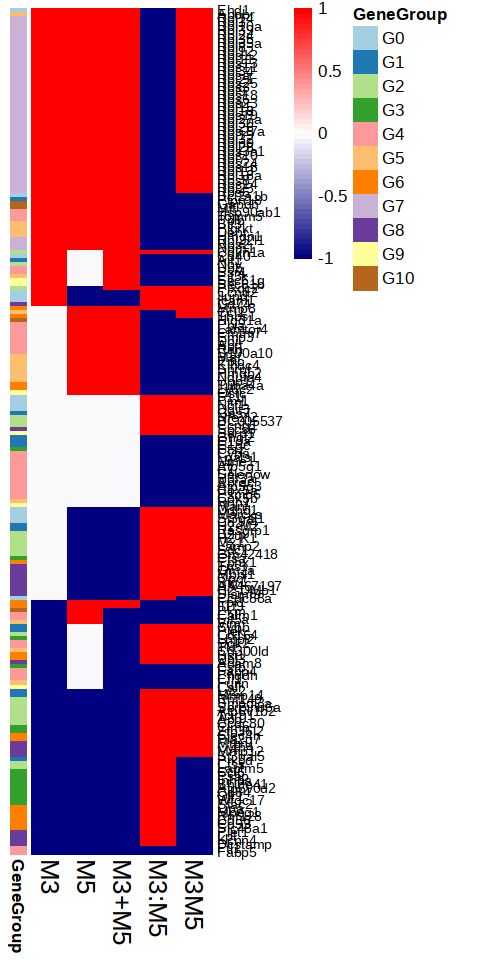

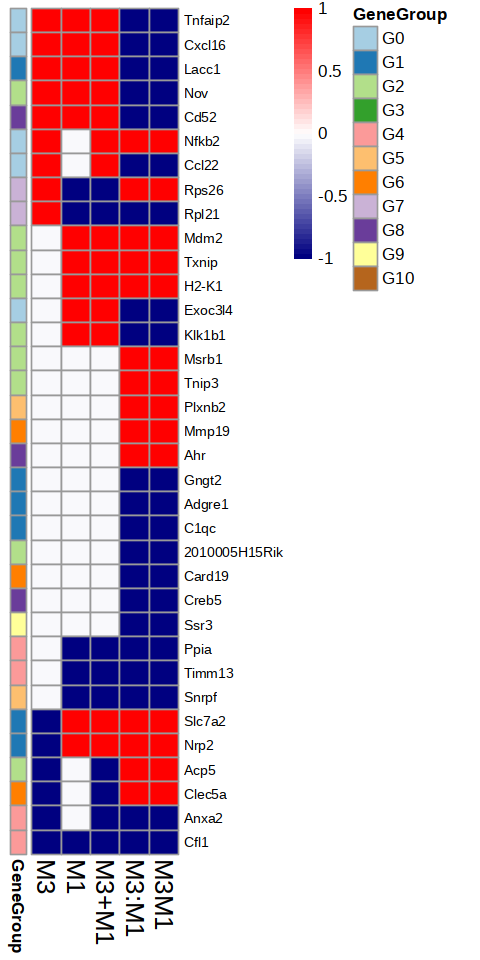

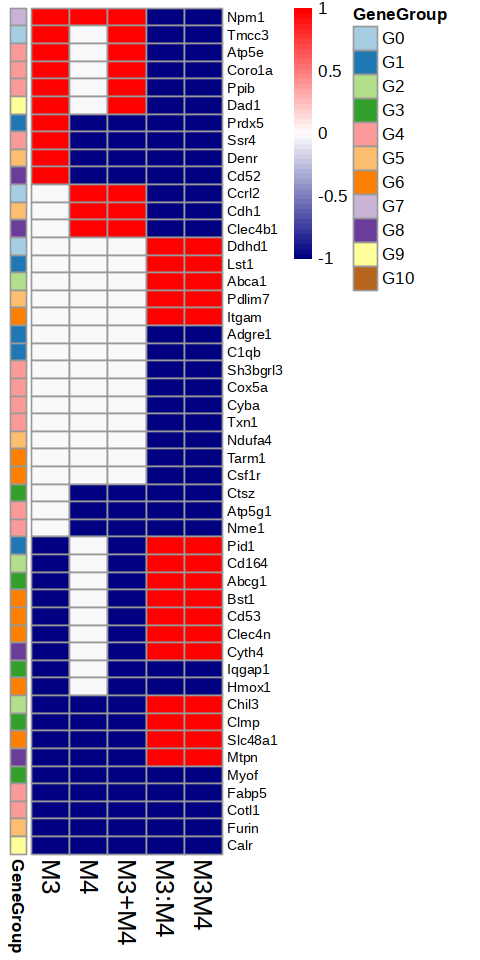

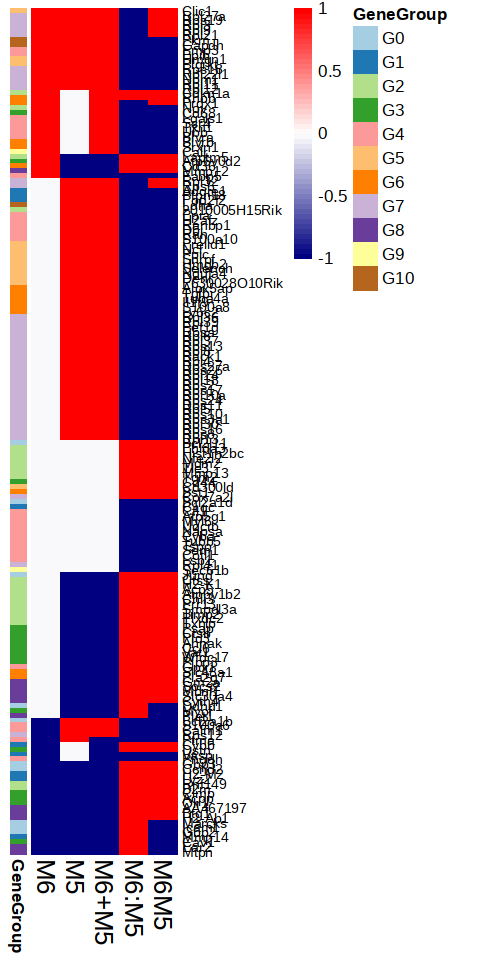

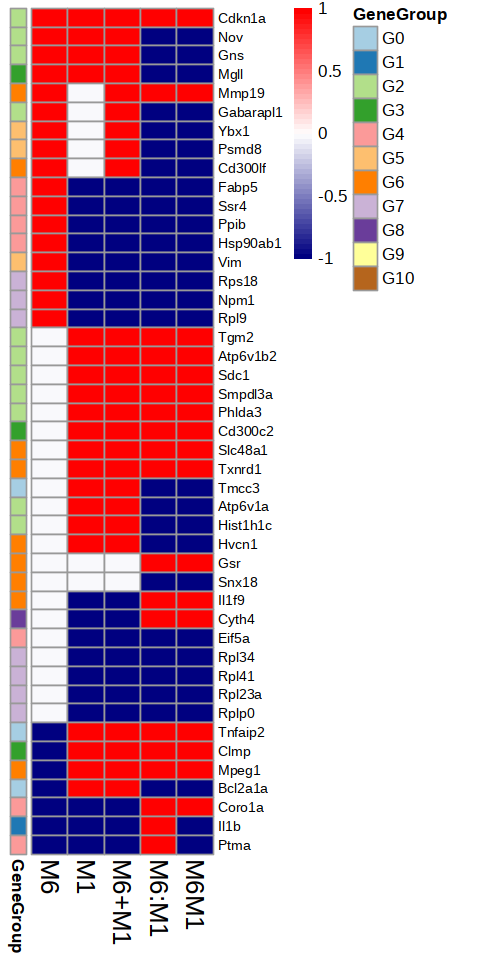

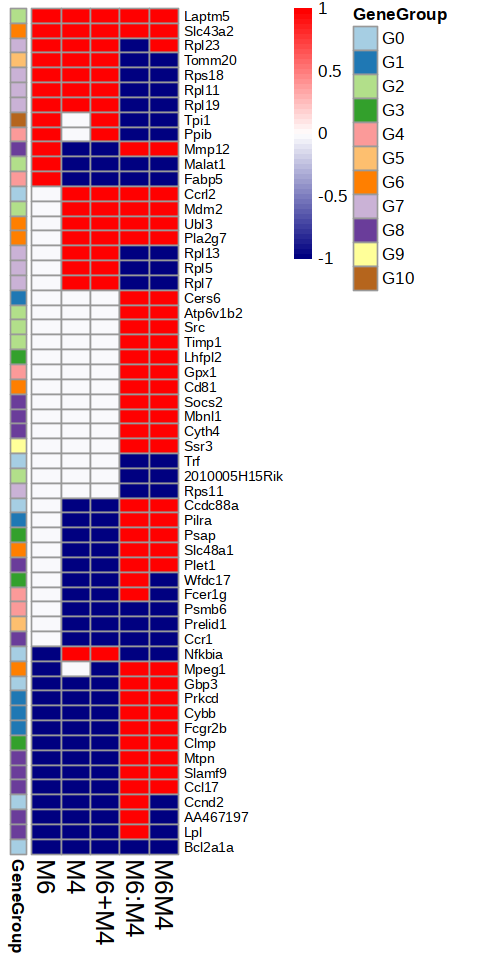

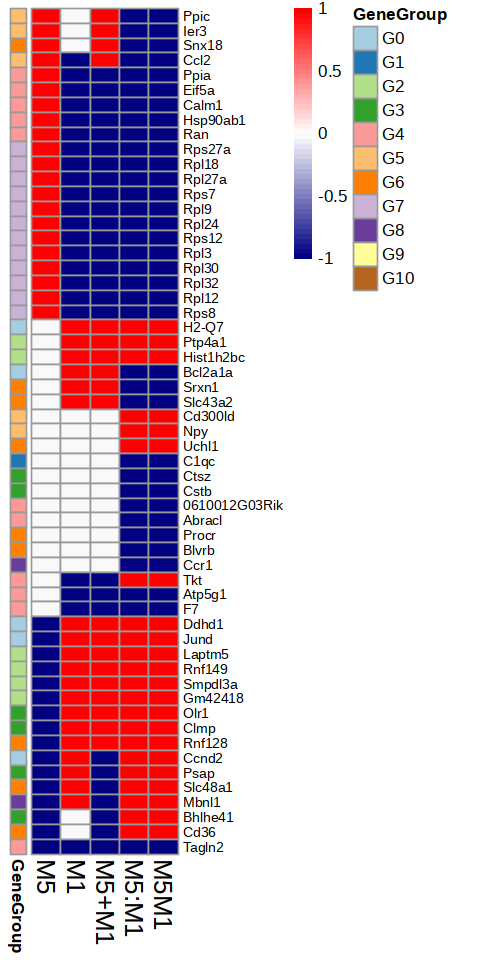

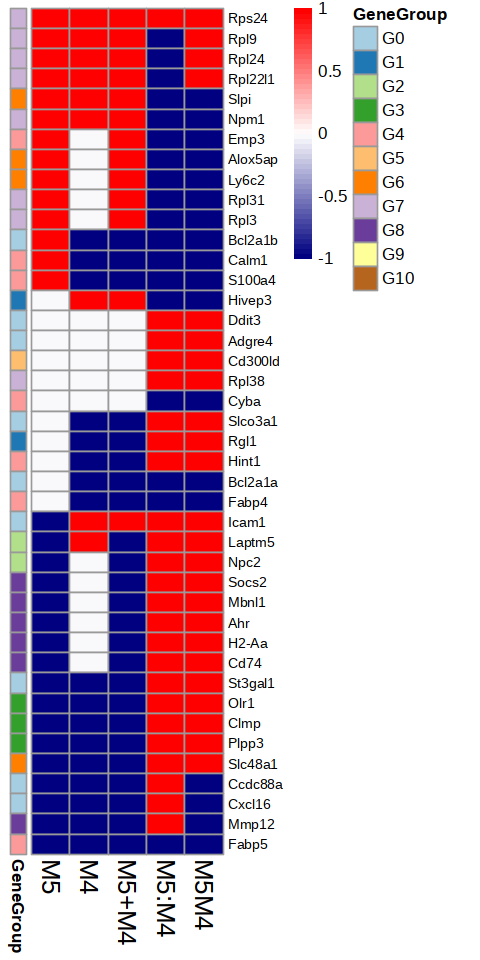

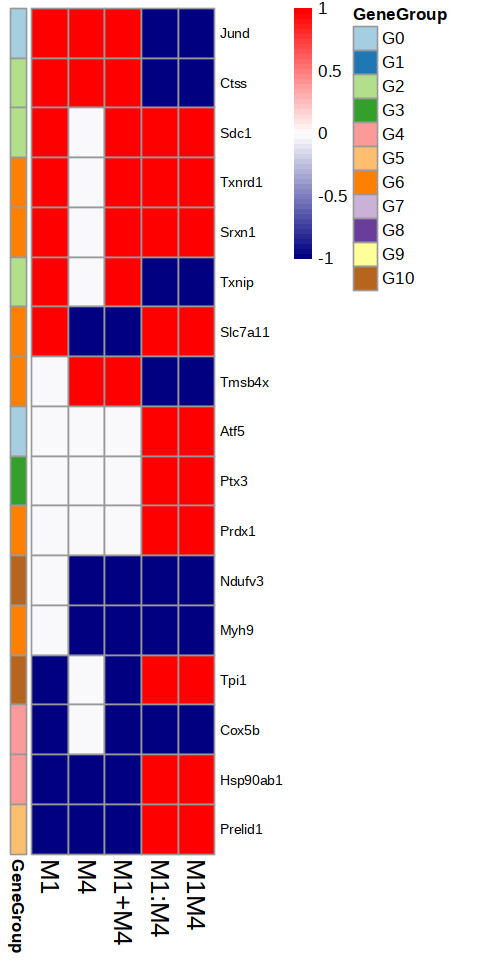

In [18]:
options(repr.plot.width=4, repr.plot.height=8)

for(elem in unique(combosInterMelt$variable)){
    
    combosInterMeltGroup = combosInterMelt[combosInterMelt$variable == elem,]
    
    g1 = unique(combosInterMeltGroup$Group1)
    g2 = unique(combosInterMeltGroup$Group2)
    
    tp = combosInterMeltGroup[,c("Group1Value", "Group2Value","value")]
    tp$g1Ag2 = rowSums(tp)
    tp$g1g2 = tp$Group1Value + tp$Group2Value
    colnames(tp) = c(g1, g2,elem, paste0(g1,g2), paste0(g1,"+",g2))
    tp = tp[,c(g1, g2,paste0(g1,"+",g2),elem, paste0(g1,g2))]
    rownames(tp) = combosInterMeltGroup$Gene
    
    myAnnot = myGeneModules[rownames(tp), , drop = FALSE]
    
    #print(tp)

    tp[tp > 0] =1
    tp[tp <  0] = -1
    tp$GeneGroup = myAnnot$GeneGroup
    tp = tp[order(-tp[,1], -tp[,2], -tp[,3], -tp[,4],-tp[,5],tp$GeneGroup),]
    tp$GeneGroup = NULL
   
    colnames(tp) <- moduleLabel(colnames(tp))
    
    tt <- pheatmap(tp,
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         clustering_method="ward.D",
         treeheight_col=0,
         treeheight_row=0,
         fontsize_row=8,fontsize_col=15,
         annotation_row = myAnnot,
         annotation_colors = annoCols,
         colorRampPalette(c("navy", "white", "red"))(50))
    
    save_pheatmap_pdf(tt, paste0("figures/", gsub(":", "_", moduleLabel(elem)), ".pdf"),
                      width=4, height=15)

}
